In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import sparse as sp
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import numpy as np
import os
import math
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

def TBU_SNM(p, phi1, phi2, omega=0, tau=0):
    """
    TBU bidireccional usando las ecuaciones de Capmany mapeadas a SNM.
    Incluye sensibilidad a la frecuencia (omega) y retardo (tau).
    """
    # Coeficientes de los acopladores
    c_a, s_a = np.sqrt(1 - p['K_a']), np.sqrt(p['K_a'])
    c_b, s_b = np.sqrt(1 - p['K_b']), np.sqrt(p['K_b'])
    
    # El multiplicador incluye la pérdida y la fase de propagación global
    multiplicador = np.sqrt(1-p['gamma_a'])*np.sqrt(1-p['gamma_b'])*np.exp(-1j*omega*tau)
    
    # Fases efectivas (programada + frecuencia)
    theta1 = phi1 + omega * tau
    theta2 = phi2 + omega * tau

    # Coeficientes de la matriz de transferencia H 
    m11 = c_a*c_b*np.sqrt(1-p['gamma_c'])*np.exp(-1j*theta1) - s_a*s_b*np.sqrt(1-p['gamma_d'])*np.exp(-1j*theta2)
    m12 = -1j*s_a*c_b*np.sqrt(1-p['gamma_c'])*np.exp(-1j*theta1) - 1j*s_b*c_a*np.sqrt(1-p['gamma_d'])*np.exp(-1j*theta2)
    m21 = -1j*s_b*c_a*np.sqrt(1-p['gamma_c'])*np.exp(-1j*theta1) - 1j*s_a*c_b*np.sqrt(1-p['gamma_d'])*np.exp(-1j*theta2)
    m22 = c_a*c_b*np.sqrt(1-p['gamma_d'])*np.exp(-1j*theta2) - s_a*s_b*np.sqrt(1-p['gamma_c'])*np.exp(-1j*theta1)

    # Matriz S local de 4x4 (mapea 4 nodos de entrada a 4 de salida) 
    # Puertos: a=0, c=1 (Entradas) | b=2, d=3 
    S_local = np.zeros((4, 4), dtype=complex)
    
    # Forward: In(a,c) -> Out(b,d)
    S_local[2, 0] = m11; S_local[2, 1] = m12
    S_local[3, 0] = m21; S_local[3, 1] = m22
    
    # Backward: In(b,d) -> Out(a,c) (Por reciprocidad Sij = Sji)
    S_local[0, 2] = m11; S_local[1, 2] = m12
    S_local[0, 3] = m21; S_local[1, 3] = m22
    
    return multiplicador * S_local
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import factorized
import matplotlib.pyplot as plt

class malla_hexagonal:
    def __init__(self, tbus_por_columna, ideal=False, seed = None):
        # 1. Configuración de geometría
        self.tbus_reales = tbus_por_columna
        self.Cols = len(tbus_por_columna)
        self.Filas = max(tbus_por_columna) 
        
        self.ideal = ideal
        self.num_puertos = self.Cols * self.Filas * 4
        self.S = sp.lil_matrix((self.num_puertos, self.num_puertos), dtype=complex)
        
        self.seed = seed
        self.params_tbus = {} 
        self.cable_loss = 1.0 if ideal else 1
        self._inicializar_defectos() 

    def _existe_tbu(self, c, f):
        """Verifica si la TBU (c, f) es parte del diseño real."""
        if c < 0 or c >= self.Cols: return False
        if f < 0 or f >= self.tbus_reales[c]: return False
        return True

    def _get_ids(self, c, f):
        """Calcula los 4 IDs globales de una TBU."""
        base = (c * self.Filas + f) * 4 
        return base, base+1, base+2, base+3

    def _inicializar_defectos(self):
        
        if self.seed is not None:
            np.random.seed(self.seed)
            
            
        K_mean, K_std = 0.5, 0.0433
        g_c_m, g_c_s = 0.0115, 0.01
        g_a_m, g_a_s = 0.0516, 0.0284
        for c in range(self.Cols):
            for f in range(self.tbus_reales[c]):
                if self.ideal:
                    self.params_tbus[(c,f)] = {
                        'K_a': 0.5, 'K_b': 0.5, 'gamma_a': 0.0, 'gamma_b': 0.0,
                        'gamma_c': 0.0, 'gamma_d': 0.0
                    }
                else:
                    self.params_tbus[(c,f)] = {
                        'K_a': np.clip(np.random.normal(K_mean, K_std), 0.0, 1.0),
                        'K_b': np.clip(np.random.normal(K_mean, K_std), 0.0, 1.0),
                        'gamma_a': np.clip(np.random.normal(g_c_m, g_c_s), 0.0, 1.0),
                        'gamma_b': np.clip(np.random.normal(g_c_m, g_c_s), 0.0, 1.0),
                        'gamma_c': np.clip(np.random.normal(g_a_m, g_a_s), 0.0, 1.0),
                        'gamma_d': np.clip(np.random.normal(g_a_m, g_a_s), 0.0, 1.0)
                    }
                    
    def colocar_tbus(self, fases_input):
        # Reiniciamos la matriz y conectamos cables antes de poner las TBUs
        self.S = sp.lil_matrix((self.num_puertos, self.num_puertos), dtype=complex)
        self._conectar_cables()
        for c in range(self.Cols):
            for f in range(self.tbus_reales[c]):
                p = self.params_tbus[(c,f)]
                phi1, phi2 = fases_input.get((c,f), (0,0))
                
                # Invocamos tu función de matriz de transferencia (asegúrate de que esté definida)
                H = TBU_no_ideal_bidireccional(p['K_a'], p['K_b'], p['gamma_a'], p['gamma_b'], 
                                               p['gamma_c'], p['gamma_d'], phi1, phi2, 0, 0)
                ids = self._get_ids(c,f)
                for i in range(4):
                    for j in range(4):
                        if H[i, j] != 0:
                            self.S[ids[i], ids[j]] = H[i, j]

    def _conectar_cables(self):
        cable = self.cable_loss
        # 1. Bucle por todas las columnas (incluimos la última para procesar sus verticales)
        for c in range(self.Cols):
            tipo = c % 4
            num_f = self.tbus_reales[c]
            
            for f in range(num_f):
                # Obtenemos los 4 IDs de la TBU actual (c, f)
                it, ib, ot, ob = self._get_ids(c, f)
                
                # --- A. CONEXIONES VERTICALES (Solo en columnas Tipo 0 y Tipo 2) ---
                if (tipo == 0 or tipo == 2) and f < num_f - 1:
                    d_it, d_ib, d_ot, d_ob = self._get_ids(c, f + 1)
                    if tipo == 0:
                        if f % 2 == 0:
                            self.S[ob, d_ot] = cable; self.S[d_ot, ob] = cable
                        else:
                            self.S[ib, d_it] = cable; self.S[d_it, ib] = cable
                    elif tipo == 2:
                        # Lógica inversa para Tipo 2 según tu diseño
                        if f % 2 == 0:
                            self.S[ib, d_it] = cable; self.S[d_it, ib] = cable
                        else:
                            self.S[ob, d_ot] = cable; self.S[d_ot, ob] = cable

                # --- B. CONEXIONES HORIZONTALES (Hacia la columna c+1) ---
                if c < self.Cols - 1:
                    if tipo == 0: # Contracción 6 -> 3
                        f_dest = f // 2
                        target = self._get_ids(c + 1, f_dest)
                        if f % 2 == 1:
                            self.S[ob, target[1]] = cable; self.S[target[1], ob] = cable
                        else:
                            self.S[ot, target[0]] = cable; self.S[target[0], ot] = cable

                    elif tipo == 1: # Expansión 3 -> 6
                        # Cada TBU en c conecta a dos en c+1
                        t_sup = self._get_ids(c + 1, 2 * f)
                        self.S[ot, t_sup[0]] = cable; self.S[t_sup[0], ot] = cable
                        t_inf = self._get_ids(c + 1, 2 * f + 1)
                        self.S[ob, t_inf[1]] = cable; self.S[t_inf[1], ob] = cable

                    elif tipo == 2: # Contracción 6 -> 4
                        if f == 0:
                            target = self._get_ids(c + 1, 0)
                            self.S[ob, target[1]] = cable; self.S[target[1], ob] = cable
                        elif f == num_f - 1: # f=5
                            target = self._get_ids(c + 1, self.tbus_reales[c+1] - 1)
                            self.S[ot, target[0]] = cable; self.S[target[0], ot] = cable
                        else:
                            f_dest = ((f - 1) // 2) + 1
                            target = self._get_ids(c + 1, f_dest)
                            if f % 2 == 0:
                                self.S[ob, target[1]] = cable; self.S[target[1], ob] = cable
                            else:
                                self.S[ot, target[0]] = cable; self.S[target[0], ot] = cable

                    elif tipo == 3: # Expansión 4 -> 6 (LÓGICA DOBLE RESTAURADA)
                        if f == 0:
                            target = self._get_ids(c + 1, 0)
                            self.S[ob, target[1]] = cable; self.S[target[1], ob] = cable
                        elif f == num_f - 1: # f=3
                            target = self._get_ids(c + 1, self.tbus_reales[c+1] - 1)
                            self.S[ot, target[0]] = cable; self.S[target[0], ot] = cable
                        else:
                            # TBUs centrales f=1, 2 conectan a DOS TBUs cada una
                            t_v_sup = self._get_ids(c + 1, 2 * f - 1)
                            self.S[ot, t_v_sup[0]] = cable; self.S[t_v_sup[0], ot] = cable
                            t_v_inf = self._get_ids(c + 1, 2 * f)
                            self.S[ob, t_v_inf[1]] = cable; self.S[t_v_inf[1], ob] = cable

    def detectar_puertos_externos(self):
        # Eliminamos la línea que reseteaba self.S
        # Solo calculamos cables si la matriz está vacía
        if self.S.nnz == 0:
            self._conectar_cables()
            
        S_csr = self.S.tocsr()
        puertos_externos = []
        for c in range(self.Cols):
            for f in range(self.tbus_reales[c]):
                ids_tbu = self._get_ids(c, f)
                for p_id in ids_tbu:
                    # Un puerto es externo si NO tiene cables conectados
                    # Buscamos en la matriz de cables (que debería ser simétrica)
                    if S_csr[p_id, :].nnz == 0:
                        puertos_externos.append(p_id)
        return puertos_externos

    def obtener_ids_perimetrales_ordenados(self):
        ids_libres = self.detectar_puertos_externos()
        info_puertos = []
        for p_id in ids_libres:
            total_tbu_id = p_id // 4
            c = total_tbu_id // self.Filas
            f = total_tbu_id % self.Filas
            p_local = p_id % 4
            x = c
            y = f * 2 + (1 if c % 2 != 0 else 0)
            
            if c == 0: borde = 'WEST'
            elif c == self.Cols - 1: borde = 'EAST'
            elif p_local == 0 or p_local == 2: borde = 'NORTH'
            else: borde = 'SOUTH'
            info_puertos.append({'id': p_id, 'c': c, 'f': f, 'p_local': p_local, 'x': x, 'y': y, 'borde': borde})
        
        # ... (resto de la función igual)

        inicio = sorted([p for p in info_puertos if p['c'] == 0 and p['f'] == 0], key=lambda x: x['p_local'], reverse=True)
        norte = sorted([p for p in info_puertos if p['borde'] == 'NORTH' and 0 < p['c'] < self.Cols-1], key=lambda x: x['x'])
        este = sorted([p for p in info_puertos if p['borde'] == 'EAST'], key=lambda x: x['y'])
        sur = sorted([p for p in info_puertos if p['borde'] == 'SOUTH' and 0 < p['c'] < self.Cols-1], key=lambda x: x['x'], reverse=True)
        
        # CORRECCIÓN AQUÍ: Añadimos x['id'] al desempate para que el puerto inferior (ID mayor) 
        # aparezca antes que el superior al subir por el Oeste.
        oeste_resto = sorted([p for p in info_puertos if p['c'] == 0 and p['f'] > 0], 
                             key=lambda x: (x['y'], x['id']), reverse=True)
        
        return [p['id'] for p in inicio + norte + este + sur + oeste_resto]

    def obtener_matriz_S_40x40(self, ids_puertos_40):
        # Aseguramos que la matriz esté en formato CSR para cálculos rápidos
        S_sparse = self.S.tocsr()
        
        # Resolvemos (I - S)x = b
        # Si ideal=True, usamos un factor de regularización para evitar matrices singulares
        reg = 1e-12 if self.ideal else 0
        I = sp.eye(self.num_puertos, format='csr') * (1 + reg)
        
        # Factorización LU para resolver rápido múltiples entradas
        solve = factorized((I - S_sparse).tocsc())
        
        num_ext = len(ids_puertos_40)
        S_puf = np.zeros((num_ext, num_ext), dtype=complex)
        
        for i in range(num_ext):
            b = np.zeros(self.num_puertos, dtype=complex)
            b[ids_puertos_40[i]] = 1.0 # Inyectamos 1 en el puerto i
            x = solve(b)
            # El resultado en los puertos externos es la respuesta de la red
            S_puf[:, i] = x[ids_puertos_40]
            
        return S_puf

class malla_SNM(malla_hexagonal):

    def __init__(self, tbus_por_columna, ideal=False, seed=None):

        super().__init__(tbus_por_columna, ideal, seed)

        # Cada puerto físico tiene un nodo de entrada (i) y uno de salida (o) [cite: 101]

        self.num_nodos = self.num_puertos * 2 

        self.G = sp.lil_matrix((self.num_nodos, self.num_nodos), dtype=complex)



    def _get_nodos(self, p_id):

        """Retorna los índices (nodo_entrada, nodo_salida) para un puerto global[cite: 101]."""

        return p_id * 2, p_id * 2 + 1



    def construir_grafo(self, fases_input):

        """Mapea la estructura al grafo de flujo inicial[cite: 210]."""

        self.G = sp.lil_matrix((self.num_nodos, self.num_nodos), dtype=complex)

        

        # 1. Conexiones internas (Nodos i -> Nodos o dentro de cada TBU) [cite: 102, 105]

        for (c, f), p in self.params_tbus.items():

            phi1, phi2 = fases_input.get((c, f), (0, 0))

            S_tbu = TBU_SNM(p, phi1, phi2)

            ids_puertos = self._get_ids(c, f)

            

            for i_local in range(4):

                for j_local in range(4):

                    if S_tbu[j_local, i_local] != 0:

                        # Nodo de entrada del puerto origen -> Nodo de salida del puerto destino

                        n_in = self._get_nodos(ids_puertos[i_local])[0]

                        n_out = self._get_nodos(ids_puertos[j_local])[1]

                        self.G[n_out, n_in] = S_tbu[j_local, i_local]



        # 2. Conexiones de cables (Nodos o -> Nodos i entre TBUs) [cite: 184]

        # Usamos la lógica de conectividad física previa

        malla_temp = malla_hexagonal(self.tbus_reales, self.ideal)

        malla_temp._conectar_cables()

        conn = malla_temp.S.tocoo()

        

        for p1, p2 in zip(conn.row, conn.col):

            if p1 < p2:

                # Cable une el nodo de salida de un puerto con el de entrada del otro [cite: 184]

                n1_in, n1_out = self._get_nodos(p1)

                n2_in, n2_out = self._get_nodos(p2)

                self.G[n2_in, n1_out] = self.cable_loss

                self.G[n1_in, n2_out] = self.cable_loss



    def resolver_matriz_total(self, ids_externos):

        """

        Calcula la matriz de scattering total entre los puertos externos[cite: 188, 24].

        Equivale a simplificar todos los nodos internos[cite: 187, 873].

        """

        # I - G representa la matriz de conexiones de toda la red [cite: 211]

        I = sp.eye(self.num_nodos, format='csr')

        A = (I - self.G.tocsr()).tocsc()

        solve = factorized(A)

        

        num_ext = len(ids_externos)

        S_total = np.zeros((num_ext, num_ext), dtype=complex)

        

        for j in range(num_ext):

            # Inyectamos señal en el nodo de entrada (i) del puerto externo j [cite: 24, 39]

            b = np.zeros(self.num_nodos, dtype=complex)

            n_in_j = self._get_nodos(ids_externos[j])[0]

            b[n_in_j] = 1.0

            

            x = solve(b)

            

            # La respuesta está en los nodos de salida (o) de los puertos externos [cite: 101, 102]

            for i in range(num_ext):

                n_out_i = self._get_nodos(ids_externos[i])[1]

                S_total[i, j] = x[n_out_i]

                

        return S_total 
class malla_SNM_completa(malla_SNM):
    def __init__(self, tbus_por_columna, ideal=False, seed=None, bits_res_fase=8):
        super().__init__(tbus_por_columna, ideal, seed)
        self.mapa_tbus = self._generar_mapa_tbus()
        self.bits_res_fase = bits_res_fase  # Guardamos la resolución del chip

        if seed is not None:
            np.random.seed(seed)
        
        # Generamos el ADN del chip ya cuantizado
        self.fases_pasivas = {}
        for coords in self.params_tbus.keys():
            # Generamos fase aleatoria
            f1_raw = np.random.uniform(0, 2*np.pi)
            f2_raw = np.random.uniform(0, 2*np.pi)
            
            # La grabamos en el "hardware" con la resolución permitida
            self.fases_pasivas[coords] = (
                self._cuantizar(f1_raw),
                self._cuantizar(f2_raw)
            )

    def _cuantizar(self, fase):
        """Método interno para aplicar la resolución de fase."""
        if self.bits_res_fase is None: return fase
        niveles = 2**self.bits_res_fase
        return np.round(fase * niveles / (2 * np.pi)) * (2 * np.pi) / niveles
        
    def _generar_mapa_tbus(self):
        """Crea el diccionario: Índice Lineal -> (Columna, Fila)"""
        mapa = {}
        contador = 0
        for c in range(self.Cols):
            for f in range(self.tbus_reales[c]):
                mapa[contador] = (c, f)
                contador += 1
        return mapa

    def programar_malla(self, config_reto, ids_maestros=None,  omega=0, tau=0, fase_comun=0):
        # 1. Inicializamos TODAS las TBUs de la malla con fases aleatorias por defecto
        """
        Lógica de Programación Segura:
        - Si la TBU es 'Maestra' (Anillo/Centro): Se calibra (borra el ADN).
        - Si no: Se suma el Ruido al ADN permanente.
        """
        ids_maestros = set(ids_maestros) if ids_maestros else set()
        fases_finales = {}
        dict_reto = dict(config_reto)

        for idx_lineal, coords in self.mapa_tbus.items():
            f_pasiva = self.fases_pasivas[coords]
            f_reto = dict_reto.get(idx_lineal, (0, 0))

            # Conversión de estados semánticos
            if f_reto == "x": phi_r = (0, 0)
            elif f_reto == "=": phi_r = (np.pi, 0)
            elif isinstance(f_reto, (int, float)):
                phi_r = (2 * np.arcsin(np.sqrt(f_reto)), 0)
            else: phi_r = f_reto

            if idx_lineal in ids_maestros:
                # MODO CALIBRADO (Autopista de luz)
                fases_finales[coords] = phi_r
            else:
                # MODO PUF (ADN + Ruido)
                fases_finales[coords] = (f_pasiva[0] + phi_r[0], f_pasiva[1] + phi_r[1])

        self.construir_grafo_espectral(fases_finales, omega, tau)

    
    def construir_grafo_espectral(self, fases_input, omega, tau):
        """
        Construye el grafo de flujo de señal considerando la fase de propagación[cite: 90, 862].
        """
        self.G = sp.lil_matrix((self.num_nodos, self.num_nodos), dtype=complex)
        
        # 1. Conexiones internas de las TBUs con dependencia espectral [cite: 102, 105]
        for (c, f), p in self.params_tbus.items():
            phi1, phi2 = fases_input.get((c, f), (0, 0))
            # Usamos tu función TBU_SNM que ya incluye omega y tau 
            S_tbu = TBU_SNM(p, phi1, phi2, omega, tau)
            ids_puertos = self._get_ids(c, f)
            
            for i_local in range(4):
                for j_local in range(4):
                    if S_tbu[j_local, i_local] != 0:
                        n_in = self._get_nodos(ids_puertos[i_local])[0]
                        n_out = self._get_nodos(ids_puertos[j_local])[1]
                        self.G[n_out, n_in] = S_tbu[j_local, i_local]
    
        # 2. Conexiones de cables con fase de retardo (tau) [cite: 184]
        # El cable también añade un desfase complejo según la frecuencia 
        fase_cable = np.exp(-1j * omega * tau) 
        
        # Usamos una malla temporal para identificar conexiones físicas [cite: 210]
        malla_temp = malla_hexagonal(self.tbus_reales, self.ideal)
        malla_temp._conectar_cables()
        conn = malla_temp.S.tocoo()
        
        for p1, p2 in zip(conn.row, conn.col):
            if p1 < p2:
                n1_in, n1_out = self._get_nodos(p1)
                n2_in, n2_out = self._get_nodos(p2)
                # Conexión bidireccional entre nodos Out e In de puertos adyacentes [cite: 184]
                self.G[n2_in, n1_out] = self.cable_loss * fase_cable
                self.G[n1_in, n2_out] = self.cable_loss * fase_cable

def graficar_salida_dbm(potencias_lineales, ids_p):
    """
    Gráfico de potencias en dBm con todos los porcentajes en vertical para evitar solapes.
    """
    suelo = -60 
    # El paper utiliza escalas logarítmicas para analizar la transmisión [cite: 862]
    potencias_dbm = 10 * np.log10(potencias_lineales + 1e-12) 
    alturas = np.maximum(potencias_dbm, suelo) - suelo
    
    plt.figure(figsize=(15, 7))
    
    # Colores: Salmón para puertos con señal (>1%), azul para el resto [cite: 850]
    colores = ['#ff7f50' if p > 0.01 else '#87ceeb' for p in potencias_lineales]
    
    plt.bar(range(len(ids_p)), alturas, bottom=suelo, 
            color=colores, edgecolor='black', alpha=0.8)
    
    for i, p in enumerate(potencias_lineales):
        es_relevante = p > 0.01
   
        # Posición base del texto (mínimo un poco por encima del suelo)
        y_pos = max(potencias_dbm[i], suelo + 1)
        
        # Configuración para que todos sean verticales
        plt.text(i, y_pos + 1, f"{p*100:.1f}%", 
                 ha='center', va='bottom', 
                 fontsize=7.5, 
                 fontweight='bold' if es_relevante else 'normal',
                 rotation=90, # <--- Todos en vertical
                 alpha=1.0 if es_relevante else 0.7)

    # Damos margen arriba para que quepan los números verticales
    plt.ylim([suelo, 15]) 
    plt.ylabel("Potencia (dBm)")
    plt.xlabel("Índice de Puerto de Salida (S)")
    plt.title("Distribución de Potencia por Puerto - Método SNM")
    
    plt.grid(axis='y', linestyle=':', alpha=0.4)
    plt.xticks(range(len(ids_p)), range(len(ids_p)), fontsize=8)
    
    plt.tight_layout()
    plt.show()
def preparar_fases(config_usuario, fase_comun=0):
    """
    Traduce estados semánticos a fases físicas añadiendo un Overall Phase Shift.
    fase_comun: Desplazamiento global que se aplica a todas las TBUs.
    """
    fases = {}
    for (tbu_id, estado) in config_usuario:
        # 1. Calculamos la fase diferencial base (la que controla el puerto de salida)
        if estado == "x":
            phi1_base, phi2_base = (0, 0)
        elif estado == "=":
            phi1_base, phi2_base = (np.pi, 0)
        elif isinstance(estado, (int, float)):
            phi1_base, phi2_base = (2 * np.arcsin(np.sqrt(estado)), 0)
        else:
            phi1_base, phi2_base = (0, 0)

        # 2. Implementamos el "Overall Phase Shift" sumando la fase común a AMBOS brazos
        # Esto es lo que te pedía tu jefe: Psi = (theta1 + theta2) / 2
        fases[tbu_id] = (phi1_base + fase_comun, phi2_base + fase_comun)
        
    return fases


def calcular_metricas_puf(p1, p2):
    # 1. Correlación de Pearson (1 = idénticos, 0 = sin relación)
    # En una buena PUF, la correlación debe ser baja
    corr, _ = pearsonr(p1, p2)
    
    # 2. Distancia Euclidiana (Cuanto mayor, más diferentes son los chips)
    dist_euclidea = np.linalg.norm(p1 - p2)
    
    # 3. Diferencia Porcentual Media (MAE en escala lineal)
    mae = np.mean(np.abs(p1 - p2)) * 100
    
    # 4. Superposición de Potencia (Similarity Score)
    # Calculamos cuánto de la potencia cae en los mismos puertos
    overlap = np.sum(np.minimum(p1, p2)) / np.sum(p1) * 100

    print("--- MÉTRICAS DE COMPARACIÓN INTER-CHIP ---")
    print(f"1. Correlación de Pearson: {corr:.4f}")
    print(f"2. Distancia Euclidiana:  {dist_euclidea:.4f}")
    print(f"3. Error Medio Absoluto:  {mae:.2f} %")
    print(f"4. Similitud de Perfil:   {overlap:.2f} %")
    print("-" * 42)
    
    if corr < 0.7:
        print("RESULTADO: Alta Unicidad. Los chips son fácilmente distinguibles. ✅")
    else:
        print("RESULTADO: Baja Unicidad. Los chips se parecen demasiado. ⚠️")




In [2]:
# --- DICCIONARIO MAESTRO DE RUTAS AL CENTRO ---
# Clave: ID del Puerto Global | Valor: Lista de (ID_TBU, Estado)
rutas_maestras_anillo = {
    0: [  
        (0, "x"), (6, "x"), (10, "x"), (16, "x"), (21, "x"), (26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    
    1: [  
        (0, "="), (6, "x"), (10, "x"), (16, "x"), (21, "x"),(26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    
    2: [  
        (9, "x"), (10, "="), (16, "x"), (21, "x"),(26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],

    3: [  
        (15, "x"), (19, "="), (20, "x"), (21, "="),(26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    
    4: [  
        (15, "x"), (9, "="), (10, "="), (16, "x"), (21, "x"), (26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    
    5: [  
        (19, "x"), (20, "x"), (21, "="), (26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    6: [  
        (28, "x"),    (29, "x"),                                          # GATEWAY (Entrada)
    (30, "x"), (31, 1- 1/6), (36,  1-1/5), (41, 1- 1/4), (40, 1- 1/3), (35, 1- 1/2) # ANILLO
    ],
    7: [  
        (34, "x"), (38, "="),  (39, "x"),                                          # GATEWAY (Entrada)
    (35, "x"), (30, 1- 1/6), (31,  1-1/5), (36, 1- 1/4), (41, 1- 1/3), (40, 1- 1/2) # ANILLO
    ],
    8: [  
        (34, "x"), (28, "="), (29, "x"),                                          # GATEWAY (Entrada)
    (30, "x"), (31, 1- 1/6), (36,  1-1/5), (41, 1- 1/4), (40, 1- 1/3), (35, 1- 1/2) # ANILLO
    ],
    9: [  
        (38, "x"), (39, "x"),                                          # GATEWAY (Entrada)
    (35, "x"), (30, 1- 1/6), (31,  1-1/5), (36, 1- 1/4), (41, 1- 1/3), (40, 1- 1/2) # ANILLO
    ],
    
    10: [  
        (47, "="), (44, "x"), (39, "x"),                                          # GATEWAY (Entrada)
    (35, "x"), (30, 1- 1/6), (31,  1-1/5), (36, 1- 1/4), (41, 1- 1/3), (40, 1- 1/2) # ANILLO
    ],
    11: [  
        (53, "x"), (57, "="),(58, "="),(54, "x"),(49, "x"),  (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    12: [  
        (53, "x"), (47, "="), (48, "x"), (49, "="), (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    13: [  
         (57, "x"),(58, "="),(54, "x"),(49, "x"),(45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    14: [  
        (66, "="), (63, "x"),(58, "x"),(54, "x"),(49, "x"), (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    
    15: [  
        (66, "x"), (63, "x"),(58, "x"),(54, "x"),(49, "x"), (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],

    16: [  
        (67, "x"), (63, "="),(58, "x"),(54, "x"),(49, "x"),(45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    17: [  
        (68, "x"), (64, "="),(59, "x"),(54, "="),(49, "x"), (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    
    18: [  
        (69, "x"), (64, "x"),(59, "x"),(54, "="),(49, "x"),(45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],

    19: [  
        (70, "x"), (65, "="),(61, "x"),(55, "x"),(50, "x"), (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    

    20: [  
        (71, "x"), (65, "x"),(61, "x"),(55, "x"),(50, "x"), (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    
    21: [  
        (71, "="), (65, "x"),(61, "x"),(55, "x"),(50, "x"), (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    
    22: [  
        (62, "x"), (61, "="),(55, "x"),(50, "x"), (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    
    23: [  
        (56, "x"), (52, "="),(51, "x"),(50, "="), (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],

    24: [  
      (56, "x"),  (62, "="), (61, "="),(55, "x"),(50, "x"),(45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],
    
    25: [  
         (52, "x"),(51, "x"),(50,"="), (45, "x"),                                          # GATEWAY (Entrada)
    (40, "x"), (35, 1- 1/6), (30,  1-1/5), (31, 1- 1/4), (36, 1- 1/3), (41, 1- 1/2) # ANILLO
    ],


    26: [
        (43, "x"), (42, "x"),                                          # GATEWAY (Entrada)
    (41, "x"), (40, 1- 1/6), (35,  1-1/5), (30, 1- 1/4), (31, 1- 1/3), (36, 1- 1/2) # ANILLO
    ],

    27: [
        (37, "x"),(33, "="),(32, "x"),                                          # GATEWAY (Entrada)
    (36, "x"), (41, 1- 1/6), (40,  1-1/5), (35, 1- 1/4), (30, 1- 1/3), (31, 1- 1/2) # ANILLO
    ],
    28: [
        (37, "x"), (43, "="), (42, "x"),                                          # GATEWAY (Entrada)
    (41, "x"), (40, 1- 1/6), (35,  1-1/5), (30, 1- 1/4), (31, 1- 1/3), (36, 1- 1/2) # ANILLO
    ],
    
    29: [
        (33, "x"),(32, "x"),                                          # GATEWAY (Entrada)
    (36, "x"), (41, 1- 1/6), (40,  1-1/5), (35, 1- 1/4), (30, 1- 1/3), (31, 1- 1/2) # ANILLO
    ],
    30: [
        (24, "="),(27, "x"),(32, "x"),                                          # GATEWAY (Entrada)
    (36, "x"), (41, 1- 1/6), (40,  1-1/5), (35, 1- 1/4), (30, 1- 1/3), (31, 1- 1/2) # ANILLO
    ],
    31: [
        (18, "x"),(14, "="),(13, "="),(17, "x"),(22, "x"),(26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    32: [
        (18, "x"),(24, "x"),(27, "x"),(32, "x"),                                          # GATEWAY (Entrada)
    (36, "x"), (41, 1- 1/6), (40,  1-1/5), (35, 1- 1/4), (30, 1- 1/3), (31, 1- 1/2) # ANILLO
    ],
    33: [
       (14, "x"),(13, "="),(17, "x"),(22, "x"),(26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    34: [
       (5, "="), (8, "x"),(13, "x"),(17, "x"),(22, "x"),(26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    35: [
       (5, "x"), (8, "x"),(13, "x"),(17, "x"),(22, "x"),(26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    36: [
       (4, "x"), (8, "="),(13, "x"),(17, "x"),(22, "x"),(26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    37: [
       (3, "x"), (7, "="),(12, "x"),(17, "="),(22, "x"),(26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    38: [
       (2, "x"), (7, "="),(11, "x"),(16, "="),(21, "x"),(26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
    39: [  
        (1, "x"), (6, "="), (10, "x"), (16, "x"), (21, "x"), (26, "x"),                                          # GATEWAY (Entrada)
    (31, "x"), (36, 1- 1/6), (41,  1-1/5), (40, 1- 1/4), (35, 1- 1/3), (30, 1- 1/2) # ANILLO
    ],
}

In [3]:
# --- DICCIONARIO MAESTRO DE RUTAS AL CENTRO ---
# Clave: ID del Puerto Global | Valor: Lista de (ID_TBU, Estado)
rutas_maestras = {
    0: [  
        (0, "x"), (6, "x"), (10, "x"), (16, "x"), (21, "x"), (26, 0.5)
    ],
    
    1: [  
        (0, "="), (6, "x"), (10, "x"), (16, "x"), (21, "x"), (26, 0.5)
    ],
    
    2: [  
        (9, "x"), (10, "="), (16, "x"), (21, "x"), (26, 0.5)
    ],

    3: [  
        (15, "x"), (19, "="), (20, "x"), (21, "="), (26, 0.5)
    ],
    
    4: [  
        (15, "x"), (9, "="), (10, "="), (16, "x"), (21, "x"), (26, 0.5)
    ],
    
    5: [  
        (19, "x"), (20, "x"), (21, "="), (26, 0.5)
    ],
    6: [  
        (28, "x"), (29, 0.5)
    ],
    7: [  
        (34, "x"), (38, "="), (39, 0.5)
    ],
    8: [  
        (34, "x"), (28, "="), (29, 0.5)
    ],
    9: [  
        (38, "x"), (39, 0.5)
    ],
    
    10: [  
        (47, "="), (44, "x"), (39, 0.5),
    ],
    11: [  
        (53, "x"), (57, "="),(58, "="),(54, "x"),(49, "x"), (45, 0.5),
    ],
    12: [  
        (53, "x"), (47, "="), (48, "x"), (49, "="), (45, 0.5)
    ],
    13: [  
         (57, "x"),(58, "="),(54, "x"),(49, "x"), (45, 0.5),
    ],
    14: [  
        (66, "="), (63, "x"),(58, "x"),(54, "x"),(49, "x"), (45, 0.5),
    ],
    
    15: [  
        (66, "x"), (63, "x"),(58, "x"),(54, "x"),(49, "x"), (45, 0.5),
    ],

    16: [  
        (67, "x"), (63, "="),(58, "x"),(54, "x"),(49, "x"), (45, 0.5),
    ],
    17: [  
        (68, "x"), (64, "="),(59, "x"),(54, "="),(49, "x"), (45, 0.5),
    ],
    
    18: [  
        (69, "x"), (64, "x"),(59, "x"),(54, "="),(49, "x"), (45, 0.5),
    ],

    19: [  
        (70, "x"), (65, "="),(61, "x"),(55, "x"),(50, "x"), (45, 0.5),
    ],
    
    
    20: [  
        (71, "x"), (65, "x"),(61, "x"),(55, "x"),(50, "x"), (45, 0.5),
    ],
    
    21: [  
        (71, "="), (65, "x"),(61, "x"),(55, "x"),(50, "x"), (45, 0.5),
    ],
    
    22: [  
        (62, "x"), (61, "="),(55, "x"),(50, "x"), (45, 0.5),
    ],
    
    23: [  
        (56, "x"), (52, "="),(51, "x"),(50, "="), (45, 0.5),
    ],

    24: [  
      (56, "x"),  (62, "="), (61, "="),(55, "x"),(50, "x"), (45, 0.5),
    ],
    
    25: [  
         (52, "x"),(51, "x"),(50,"="), (45, 0.5),
    ],


    26: [
        (43, "x"), (42, 0.5)
    ],

    27: [
        (37, "x"),(33, "="),(32, 0.5)
    ],
    28: [
        (37, "x"), (43, "="),  (42, 0.5)
    ],
    
    29: [
        (33, "x"),(32, 0.5)
    ],
    30: [
        (24, "="),(27, "x"),(32, 0.5)
    ],
    31: [
        (18, "x"),(14, "="),(13, "="),(17, "x"),(22, "x"),(26, 0.5)
    ],
    32: [
        (18, "x"),(24, "x"),(27, "x"),(32, 0.5)
    ],
    33: [
       (14, "x"),(13, "="),(17, "x"),(22, "x"),(26, 0.5)
    ],
    34: [
       (5, "="), (8, "x"),(13, "x"),(17, "x"),(22, "x"),(26, 0.5)
    ],
    35: [
       (5, "x"), (8, "x"),(13, "x"),(17, "x"),(22, "x"),(26, 0.5)
    ],
    36: [
       (4, "x"), (8, "="),(13, "x"),(17, "x"),(22, "x"),(26, 0.5)
    ],
    37: [
       (3, "x"), (7, "="),(12, "x"),(17, "="),(22, "x"),(26, 0.5)
    ],
    38: [
       (2, "x"), (7, "="),(11, "x"),(16, "="),(21, "x"),(26, 0.5)
    ],
    39: [  
        (1, "x"), (6, "="), (10, "x"), (16, "x"), (21, "x"), (26, 0.5)
    ],
}

In [4]:
# --- 4. MOTOR DE SIMULACIÓN ---

def generar_configuracion_totalmente_aleatoria(malla, seed, bits_res=8):
    """
    Genera retos aleatorios considerando la resolución del controlador (DAC).
    """
    np.random.seed(seed)
    config = []
    
    # Usamos mapa_tbus para asegurar que solo generamos fases para TBUs reales
    for idx in malla.mapa_tbus.keys():
        f1 = np.random.uniform(0, 2*np.pi)
        f2 = np.random.uniform(0, 2*np.pi)
        
        # Opcional: Si quieres que el reto también esté cuantizado (muy recomendado)
        if bits_res:
            niveles = 2**bits_res
            f1 = np.round(f1 * niveles / (2*np.pi)) * (2*np.pi) / niveles
            f2 = np.round(f2 * niveles / (2*np.pi)) * (2*np.pi) / niveles
            
        config.append((idx, (f1, f2)))
    return config
def procesar_un_puerto(idx_in, p_humano, malla, ids_activos, dict_rutas, ids_maestros, config_fondo):
    fondo_dict = dict(config_fondo)
    conf_puerto = fondo_dict.copy()
    if p_humano in dict_rutas:
        for tbu_id, estado in dict_rutas[p_humano]: conf_puerto[tbu_id] = estado
    malla.programar_malla(list(conf_puerto.items()), ids_maestros=ids_maestros)
    return np.abs(malla.resolver_matriz_total(ids_activos)[:, idx_in])**2


def ejecutar_y_guardar_chip(c_idx, tbus_columnas, ids_activos, indices_validos, rutas_anillo, rutas_centro,res_fase, num_retos, directorio):
    seed_hw = 5000 + c_idx
    os.makedirs(directorio, exist_ok=True)
    filename = os.path.join(directorio, f"chip_{seed_hw}.npz")
    if os.path.exists(filename): return
    
    # IMPORTANTE: Aquí pasas la resolución de fabricación (ADN)
    
    malla_chip = malla_SNM_completa(tbus_columnas, seed=seed_hw, bits_res_fase=res_fase)
    tbus_maestras_anillo = {t[0] for ruta in rutas_anillo.values() for t in ruta}
    
    # 1. BASE (Pasamos res_fase también al generador de retos para simular el DAC)
    ruido_base = generar_configuracion_totalmente_aleatoria(malla_chip, seed=seed_hw + 777, bits_res=res_fase)
    
    res_base_anillo = np.zeros((len(ids_activos), len(ids_activos)), dtype=np.float32)
    for idx, p_in in enumerate(ids_activos):
        res_base_anillo[:, idx] = procesar_un_puerto(idx, indices_validos[idx], malla_chip, 
                                                   ids_activos, rutas_anillo, tbus_maestras_anillo, ruido_base)
    # 2. RETOS
    retos_anillo = []
    for r in range(num_retos):
        ruido_reto = generar_configuracion_totalmente_aleatoria(malla_chip, seed=seed_hw + r + 1, bits_res=res_fase)
        m_reto = np.zeros_like(res_base_anillo)
        for idx, p_in in enumerate(ids_activos):
            m_reto[:, idx] = procesar_un_puerto(idx, indices_validos[idx], malla_chip, 
                                               ids_activos, rutas_anillo, tbus_maestras_anillo, ruido_reto)
        retos_anillo.append(m_reto)
        
    np.savez_compressed(filename, base_anillo=res_base_anillo, anillo=np.array(retos_anillo), seed_hw=seed_hw)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. CONFIGURACIÓN DE PRUEBA (40 PUERTOS) ---
tbus_columnas = [6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6]
malla_verif = malla_SNM_completa(tbus_columnas, seed=123)
# Obtenemos todos los 40 IDs para la prueba inicial
ids_40 = malla_verif.obtener_ids_perimetrales_ordenados()
indices_40 = list(range(40))

# Directorio temporal
directorio_test = "verificacion_puf"
n_retos_test = 1

# --- 2. EJECUTAR SIMULACIÓN DE 1 CHIP ---
print("🚀 Generando datos de verificación para Chip 5000...")
# Nota: Asegúrate de tener definidos 'rutas_maestras_anillo' y 'rutas_maestras' 
# de tus mensajes anteriores en el entorno de ejecución.
ejecutar_y_guardar_chip(0, tbus_columnas, ids_40, indices_40, 
                        rutas_maestras_anillo, rutas_maestras, n_retos_test, directorio_test)

# --- 3. CARGAR Y PROCESAR ---
data = np.load(os.path.join(directorio_test, "chip_5000.npz"))
base_db = 10 * np.log10(data['base_anillo'] + 1e-12)
reto_db = 10 * np.log10(data['anillo'][0] + 1e-12)
delta = reto_db - base_db

# --- 4. VISUALIZACIÓN ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Mapa 1: La Base (El Anillo "Limpio" + ADN + Ruido Base)
sns.heatmap(base_db, ax=axes[0], cmap='magma', cbar_kws={'label': 'Potencia (dB)'})
axes[0].set_title("A. MATRIZ BASE (Referencia)\nAnillo Calibrado + Fondo Fijo", fontweight='bold')

# Mapa 2: El Reto (El Anillo "Limpio" + ADN + Ruido Reto)
sns.heatmap(reto_db, ax=axes[1], cmap='magma', cbar_kws={'label': 'Potencia (dB)'})
axes[1].set_title("B. MATRIZ RETO\nAnillo Calibrado + Fondo Nuevo", fontweight='bold')

# Mapa 3: La Firma Diferencial (Delta)
# Aquí es donde el anillo debe desaparecer
sns.heatmap(delta, ax=axes[2], cmap='RdBu_r', center=0, cbar_kws={'label': 'Diferencia (dB)'})
axes[2].set_title("C. FIRMA DIFERENCIAL (Δ)\nReto - Base (Solo Caos)", fontweight='bold', color='red')

for ax in axes:
    ax.set_xlabel("Puerto de Entrada")
    ax.set_ylabel("Puerto de Salida")

plt.tight_layout()
plt.show()

# --- COMPROBACIÓN MATEMÁTICA ---
correlacion_con_anillo = np.corrcoef(base_db.flatten(), reto_db.flatten())[0,1]
correlacion_delta = np.corrcoef(delta.flatten(), delta.flatten())[0,1] # (Solo para estructura)

print(f"📊 Correlación Analógica (Con Anillo): {correlacion_con_anillo:.4f}")
print("💡 Si la resta ha funcionado, el Mapa C no debería mostrar la forma del anillo del Mapa A.")

In [5]:
from joblib import Parallel, delayed
# --- 1. CONFIGURACIÓN FINAL ---
tbus_columnas = [6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6, 4, 6, 3, 6]
# Filtramos los 28 puertos reales (tu diseño)
indices_validos = [i for i in range(40) if i < 22 or i > 33]

malla_final = malla_SNM_completa(tbus_columnas, seed=123)
ids_40 = malla_final.obtener_ids_perimetrales_ordenados()
# IDs físicos reales de los 28 puertos
ids_activos = [ids_40[i] for i in indices_validos]

n_chips = 1000
num_retos = 1000
directorio_data = "base_datos_puf_FINAL_TESIS_FASES_8BITS_1000CHIPS_1000RETOS"
n_jobs = -1 # Usar todos los procesadores
res_fase = 8

# --- 2. MOTOR DE SIMULACIÓN PARALELIZADO ---
print(f"🚀 Iniciando simulación masiva: {n_chips} chips x {num_retos} retos...")

# Esto es lo que realmente usa todos tus núcleos
Parallel(n_jobs=n_jobs)(
    delayed(ejecutar_y_guardar_chip)(
        c, tbus_columnas, ids_activos, indices_validos, 
        rutas_maestras_anillo, rutas_maestras, res_fase, num_retos, directorio_data
    ) for c in tqdm(range(n_chips), desc="Simulando en Paralelo")
)

print(f"\n✅ Base de datos completada en '{directorio_data}/'.")

🚀 Iniciando simulación masiva: 1000 chips x 1000 retos...


Simulando en Paralelo: 100%|███████████████████████████████████████████████████████| 1000/1000 [00:14<00:00, 70.02it/s]



✅ Base de datos completada en 'base_datos_puf_FINAL_TESIS_FASES_8BITS_1000CHIPS_1000RETOS/'.


In [8]:
import numpy as np
import os
import math
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- 1. FUNCIONES DE BINARIZACIÓN (LEHMER + GRAY) ---

def binarizar_puf_lehmer_por_columnas(matriz_lineal):
    """Binariza la matriz procesando cada columna (puerto de entrada) de forma independiente."""
    vector_bits_total = []
    
    # Procesamos cada columna (experimento de inyección individual)
    for c in range(matriz_lineal.shape[1]):
        columna = 10 * np.log10(matriz_lineal[:, c] + 1e-12)
        n = len(columna)
        
        # Coeficientes de Lehmer para esta columna (N=28)
        r = []
        for j in range(1, n):
            # Ranking relativo dentro de la misma inyección
            cuenta = np.sum(columna[:j] < columna[j])
            r.append(cuenta)

        # Gray + Bitstring para esta columna
        for j, rj in enumerate(r):
            n_bits = math.ceil(math.log2(j + 2))
            gj = rj ^ (rj >> 1)
            vector_bits_total.append(format(gj, f"0{n_bits}b"))
    
    return "".join(vector_bits_total)

def calcular_hd(s1, s2):
    """Distancia de Hamming normalizada."""
    diffs = sum(c1 != c2 for c1, c2 in zip(s1, s2))
    return diffs / len(s1)

# --- 2. CARGA Y PROCESAMIENTO ---
directorio_data = "base_datos_puf_FINAL_TESIS_FASES_8BITS_1000CHIPS_1000RETOS"
archivos = sorted([f for f in os.listdir(directorio_data) if f.endswith('.npz')])

print(f"📦 Analizando {len(archivos)} chips con binarización por columnas...")

llaves_inter_chip = [] 
llaves_inter_reto = [] 

# Procesamos para Unicidad (Inter-Chip) usando el método de columnas
for f in tqdm(archivos, desc="Binarizando para Unicidad"):
    data = np.load(os.path.join(directorio_data, f))
    # Cambiamos aquí: usamos la nueva función y ya no necesitamos data['base_anillo']
    bits = binarizar_puf_lehmer_por_columnas(data['anillo'][0])
    llaves_inter_chip.append(bits)

# Procesamos para Independencia (Inter-Reto) del primer chip
data_c0 = np.load(os.path.join(directorio_data, archivos[0]))
for i in range(len(data_c0['anillo'])):
    # Cambiamos aquí también
    bits = binarizar_puf_lehmer_por_columnas(data_c0['anillo'][i])
    llaves_inter_reto.append(bits)

# --- 3. CÁLCULO DE DISTANCIAS DE HAMMING ---
hd_unicidad = [calcular_hd(llaves_inter_chip[i], llaves_inter_chip[j]) 
               for i in range(len(llaves_inter_chip)) 
               for j in range(i + 1, len(llaves_inter_chip))]

hd_independencia = [calcular_hd(llaves_inter_reto[i], llaves_inter_reto[j]) 
                    for i in range(len(llaves_inter_reto)) 
                    for j in range(i + 1, len(llaves_inter_reto))]

# --- 4. VISUALIZACIÓN ---
plt.figure(figsize=(12, 6))
sns.kdeplot(hd_unicidad, fill=True, color="royalblue", label=f"Unicidad μ={np.mean(hd_unicidad):.4f}")
sns.kdeplot(hd_independencia, fill=True, color="orange", label=f"Independencia μ={np.mean(hd_independencia):.4f}")

plt.axvline(0.5, color='red', linestyle='--', alpha=0.6, label="Ideal (0.5)")
plt.title("Evaluación HD (Método por Columnas)", fontweight='bold', fontsize=14)
plt.xlabel("Distancia de Hamming Normalizada")
plt.ylabel("Densidad")
plt.xlim([0.3, 0.7])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("-" * 50)
print(f"📊 RESULTADOS FINALES (Binarización por Columnas):")
print(f" > UNICIDAD MEDIA:      {np.mean(hd_unicidad):.4f}")
print(f" > INDEPENDENCIA MEDIA: {np.mean(hd_independencia):.4f}")
print(f" > LONGITUD DE LLAVE:   {len(llaves_inter_chip[0])} bits")
print("-" * 50)

📦 Analizando 1000 chips con binarización por columnas...


Binarizando para Unicidad: 100%|███████████████████████████████████████████████████| 1000/1000 [00:50<00:00, 19.62it/s]


KeyboardInterrupt: 

📦 Procesando 1000 chips...


Binarizando Retos: 100%|██████████████████████████████████████████████████████████| 1000/1000 [00:09<00:00, 100.45it/s]


🧮 Calculando Distancias de Hamming...


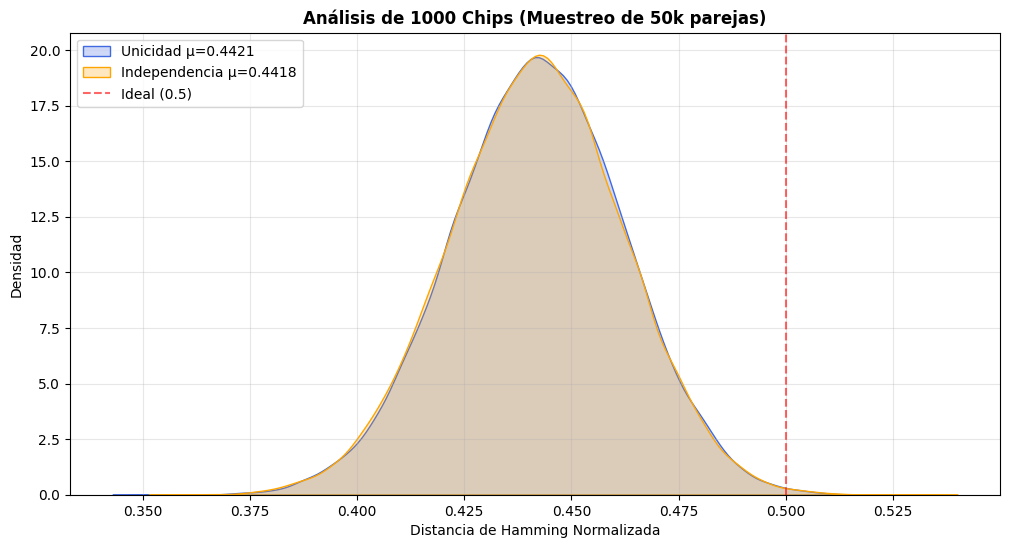

✅ Análisis completado. Longitud de llave: 3052 bits.


In [9]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random

# --- 1. BINARIZACIÓN OPTIMIZADA (Saca directamente Arrays de NumPy) ---
def binarizar_puf_rapido(matriz_lineal):
    bits_list = []
    # Procesamos por columnas
    for c in range(matriz_lineal.shape[1]):
        columna = 10 * np.log10(matriz_lineal[:, c] + 1e-12)
        n = len(columna)
        
        # Lehmer + Gray
        for j in range(1, n):
            rj = np.sum(columna[:j] < columna[j]) # Ranking
            n_bits = int(np.ceil(np.log2(j + 1)))
            gj = rj ^ (rj >> 1) # Gray
            # Convertimos el entero a sus bits individuales
            bits_list.append([(gj >> i) & 1 for i in reversed(range(n_bits))])
    
    # Devolvemos un array de booleanos (1s y 0s)
    return np.concatenate(bits_list).astype(bool)

# --- 2. CARGA Y PROCESAMIENTO ---
directorio_data = "base_datos_puf_FINAL_TESIS_FASES_8BITS_1000CHIPS_1000RETOS"
archivos = sorted([f for f in os.listdir(directorio_data) if f.endswith('.npz')])

print(f"📦 Procesando {len(archivos)} chips...")

# Cargamos y binarizamos (esto es rápido)
chips_bits = []
for f in tqdm(archivos[:1000], desc="Binarizando Chips"): # Limitamos a 1000 por si acaso
    data = np.load(os.path.join(directorio_data, f))
    chips_bits.append(binarizar_puf_rapido(data['anillo'][0]))

# Independencia (usamos el chip 0)
data_c0 = np.load(os.path.join(directorio_data, archivos[0]))
retos_bits = [binarizar_puf_rapido(r) for r in tqdm(data_c0['anillo'], desc="Binarizando Retos")]

chips_bits = np.array(chips_bits)
retos_bits = np.array(retos_bits)

# --- 3. CÁLCULO DE DISTANCIAS (MUESTREO ALEATORIO) ---
def fast_hamming_sampling(bit_matrix, n_pairs=50000):
    n_items = bit_matrix.shape[0]
    hds = []
    for _ in range(n_pairs):
        i, j = random.sample(range(n_items), 2)
        # Comparación vectorial XOR + mean (MUY RÁPIDO)
        hd = np.mean(bit_matrix[i] != bit_matrix[j])
        hds.append(hd)
    return hds

print("🧮 Calculando Distancias de Hamming...")
hd_unicidad = fast_hamming_sampling(chips_bits)
hd_independencia = fast_hamming_sampling(retos_bits)

# --- 4. VISUALIZACIÓN ---
plt.figure(figsize=(12, 6))
sns.kdeplot(hd_unicidad, fill=True, color="royalblue", label=f"Unicidad μ={np.mean(hd_unicidad):.4f}")
sns.kdeplot(hd_independencia, fill=True, color="orange", label=f"Independencia μ={np.mean(hd_independencia):.4f}")

plt.axvline(0.5, color='red', linestyle='--', alpha=0.6, label="Ideal (0.5)")
plt.title(f"Análisis de {len(archivos)} Chips", fontweight='bold')
plt.xlabel("Distancia de Hamming Normalizada")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"✅ Análisis completado. Longitud de llave: {chips_bits.shape[1]} bits.")

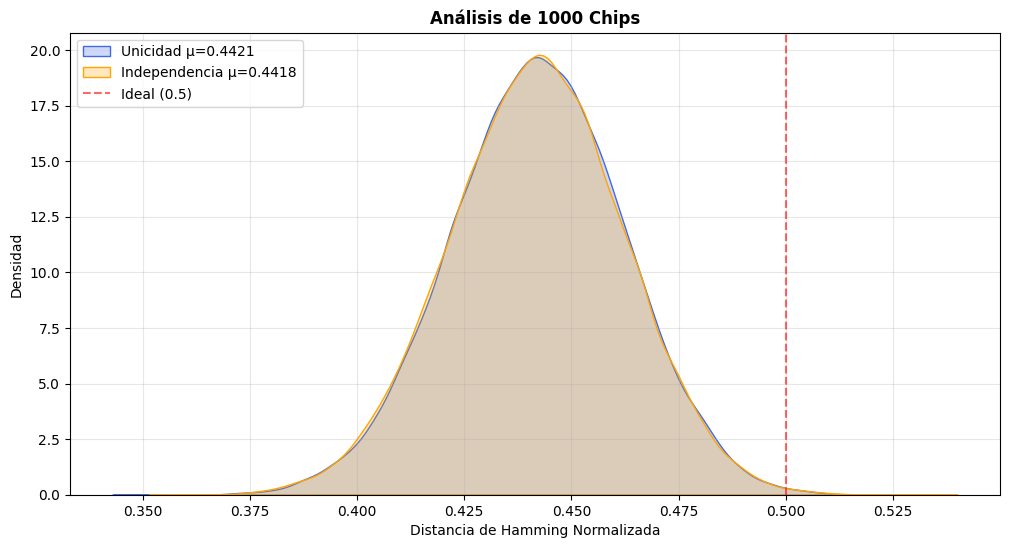

✅ Análisis completado. Longitud de llave: 3052 bits.


In [10]:
# --- 4. VISUALIZACIÓN ---
plt.figure(figsize=(12, 6))
sns.kdeplot(hd_unicidad, fill=True, color="royalblue", label=f"Unicidad μ={np.mean(hd_unicidad):.4f}")
sns.kdeplot(hd_independencia, fill=True, color="orange", label=f"Independencia μ={np.mean(hd_independencia):.4f}")

plt.axvline(0.5, color='red', linestyle='--', alpha=0.6, label="Ideal (0.5)")
plt.title(f"Análisis de {len(archivos)} Chips", fontweight='bold')
plt.xlabel("Distancia de Hamming Normalizada")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"✅ Análisis completado. Longitud de llave: {chips_bits.shape[1]} bits.")

📦 Extrayendo vectores analógicos de 1000 chips...


Procesando Independencia: 100%|█████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 28887.98it/s]


🧮 Calculando distancias Euclídeas...


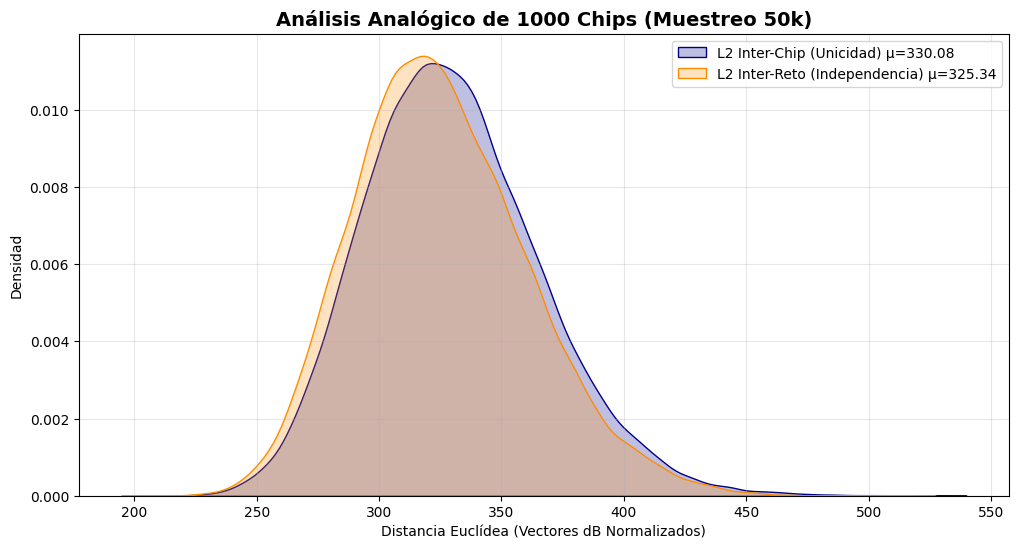

--------------------------------------------------
📊 RESULTADO DE LA HUELLA ANALÓGICA:
 > MEDIA UNICIDAD (L2): 330.0821
 > MEDIA INDEP. (L2):   325.3392
 > RATIO U/I:           1.0146
--------------------------------------------------


In [11]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random

# --- 1. EXTRACCIÓN Y NORMALIZACIÓN DE VECTORES ---
def obtener_vector_analitico(matriz_lineal):
    # Normalizamos la potencia total a 1 para comparar la "huella" y no el brillo global
    matriz_norm = matriz_lineal / (np.sum(matriz_lineal) + 1e-15)
    # Pasamos a dB para resaltar las diferencias en puertos de baja potencia
    vector_db = 10 * np.log10(matriz_norm + 1e-12)
    return vector_db.flatten()

# --- 2. CARGA DE DATOS ---
directorio_data = "base_datos_puf_FINAL_TESIS_FASES_8BITS_1000CHIPS_1000RETOS"
archivos = sorted([f for f in os.listdir(directorio_data) if f.endswith('.npz')])

print(f"📦 Extrayendo vectores analógicos de {len(archivos)} chips...")

vectores_chips = []
for f in tqdm(archivos, desc="Procesando Unicidad"):
    data = np.load(os.path.join(directorio_data, f))
    vectores_chips.append(obtener_vector_analitico(data['anillo'][0]))

# Independencia (Retos del Chip 0)
data_c0 = np.load(os.path.join(directorio_data, archivos[0]))
vectores_retos = [obtener_vector_analitico(r) for r in tqdm(data_c0['anillo'], desc="Procesando Independencia")]

vectores_chips = np.array(vectores_chips)
vectores_retos = np.array(vectores_retos)

# --- 3. CÁLCULO DE L2 (MUESTREO ALEATORIO VELOZ) ---
def fast_l2_sampling(matrix, n_pairs=50000):
    n_items = matrix.shape[0]
    l2_dists = []
    # Generamos índices aleatorios de una vez para mayor velocidad
    idx_i = np.random.randint(0, n_items, n_pairs)
    idx_j = np.random.randint(0, n_items, n_pairs)
    
    for i, j in zip(idx_i, idx_j):
        if i == j: continue # Evitamos comparar el mismo
        # Distancia Euclídea vectorial
        dist = np.linalg.norm(matrix[i] - matrix[j])
        l2_dists.append(dist)
    return l2_dists

print("🧮 Calculando distancias Euclídeas...")
l2_u = fast_l2_sampling(vectores_chips)
l2_i = fast_l2_sampling(vectores_retos)

# --- 4. VISUALIZACIÓN ---
plt.figure(figsize=(12, 6))
sns.kdeplot(l2_u, fill=True, color="darkblue", label=f"L2 Inter-Chip (Unicidad) μ={np.mean(l2_u):.2f}")
sns.kdeplot(l2_i, fill=True, color="darkorange", label=f"L2 Inter-Reto (Independencia) μ={np.mean(l2_i):.2f}")

plt.title(f"Análisis Analógico de {len(archivos)} Chips (Muestreo 50k)", fontweight='bold', fontsize=14)
plt.xlabel("Distancia Euclídea (Vectores dB Normalizados)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

ratio = np.mean(l2_u) / np.mean(l2_i)
print("-" * 50)
print(f"📊 RESULTADO DE LA HUELLA ANALÓGICA:")
print(f" > MEDIA UNICIDAD (L2): {np.mean(l2_u):.4f}")
print(f" > MEDIA INDEP. (L2):   {np.mean(l2_i):.4f}")
print(f" > RATIO U/I:           {ratio:.4f}")
print("-" * 50)

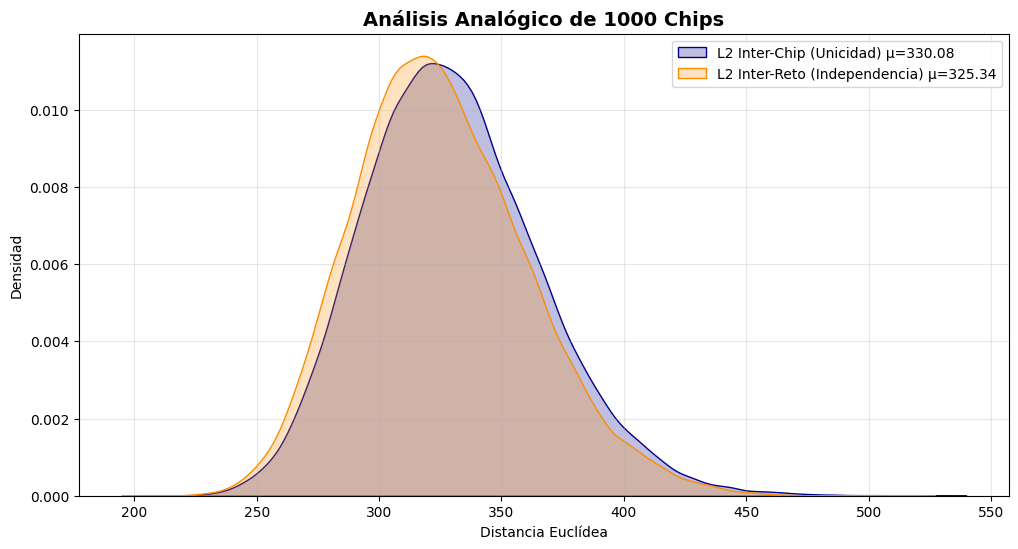

--------------------------------------------------
📊 RESULTADO DE LA HUELLA ANALÓGICA:
 > MEDIA UNICIDAD (L2): 330.0821
 > MEDIA INDEP. (L2):   325.3392
 > RATIO U/I:           1.0146
--------------------------------------------------


In [13]:
# --- 4. VISUALIZACIÓN ---
plt.figure(figsize=(12, 6))
sns.kdeplot(l2_u, fill=True, color="darkblue", label=f"L2 Inter-Chip (Unicidad) μ={np.mean(l2_u):.2f}")
sns.kdeplot(l2_i, fill=True, color="darkorange", label=f"L2 Inter-Reto (Independencia) μ={np.mean(l2_i):.2f}")

plt.title(f"Análisis Analógico de {len(archivos)} Chips", fontweight='bold', fontsize=14)
plt.xlabel("Distancia Euclídea")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

ratio = np.mean(l2_u) / np.mean(l2_i)
print("-" * 50)
print(f"📊 RESULTADO DE LA HUELLA ANALÓGICA:")
print(f" > MEDIA UNICIDAD (L2): {np.mean(l2_u):.4f}")
print(f" > MEDIA INDEP. (L2):   {np.mean(l2_i):.4f}")
print(f" > RATIO U/I:           {ratio:.4f}")
print("-" * 50)

📦 Procesando 10 chips para métricas de calidad de bit...


Generando llaves: 100%|███████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 179.05it/s]


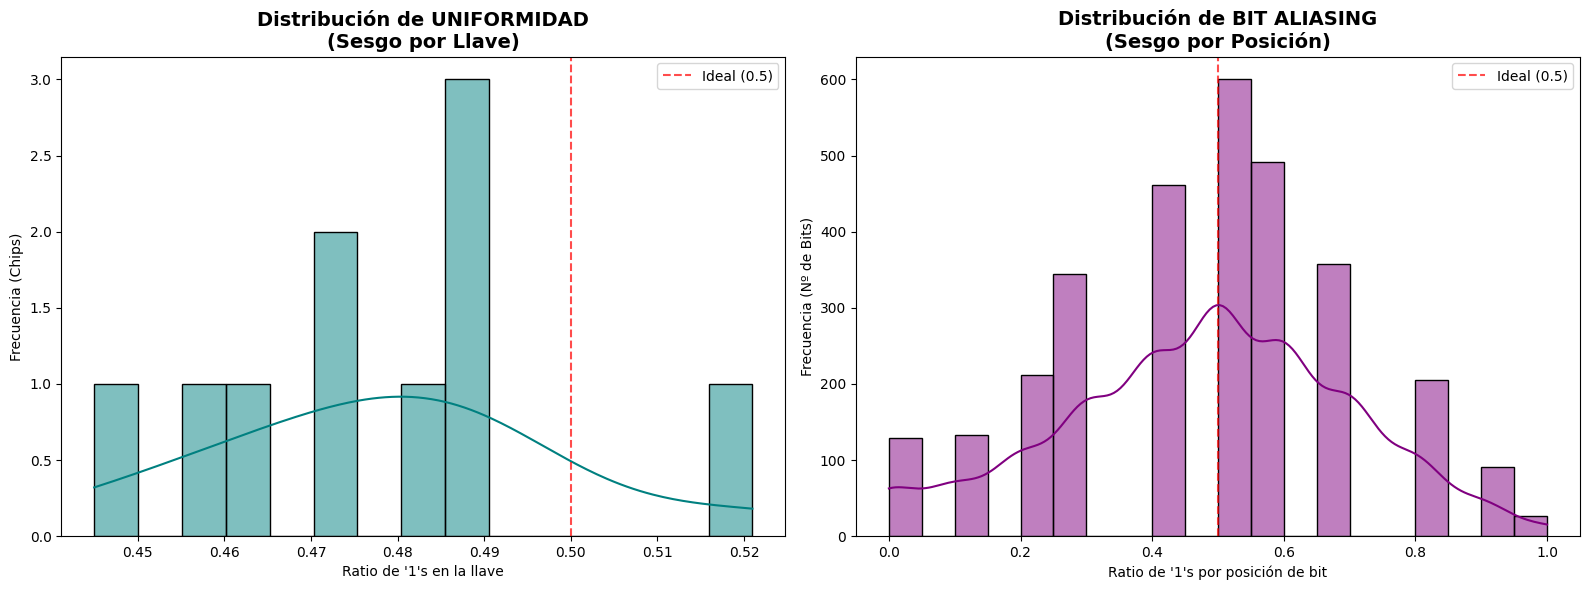

--------------------------------------------------
📊 MÉTRICAS DE CALIDAD DE BIT:
 > UNIFORMIDAD MEDIA:  0.4789 (Ideal: 0.5000)
 > BIT ALIASING MEDIO: 0.4789 (Ideal: 0.5000)
 > DESVIACIÓN ST. BA:  0.2207 (Menor es mejor)
--------------------------------------------------


In [36]:
import numpy as np
import os
import math
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- 1. FUNCIONES DE BINARIZACIÓN (LEHMER + GRAY) ---

def binarizar_puf_lehmer_por_columnas(matriz_lineal):
    """Binariza la matriz procesando cada columna (puerto de entrada) de forma independiente."""
    vector_bits_total = []
    
    # Procesamos cada columna (experimento de inyección individual)
    for c in range(matriz_lineal.shape[1]):
        columna = 10 * np.log10(matriz_lineal[:, c] + 1e-12)
        n = len(columna)
        
        # Coeficientes de Lehmer para esta columna (N=28)
        r = []
        for j in range(1, n):
            cuenta = np.sum(columna[:j] < columna[j])
            r.append(cuenta)

        # Gray + Bitstring para esta columna
        for j, rj in enumerate(r):
            n_bits = math.ceil(math.log2(j + 2))
            gj = rj ^ (rj >> 1)
            vector_bits_total.append(format(gj, f"0{n_bits}b"))
    
    return "".join(vector_bits_total)

# --- 2. CARGA Y PROCESAMIENTO ---
directorio_data = "base_datos_puf_FINAL_TESIS_FASES_8BITS"
archivos = sorted([f for f in os.listdir(directorio_data) if f.endswith('.npz')])

print(f"📦 Procesando {len(archivos)} chips para métricas de calidad de bit...")

llaves_inter_chip = [] 

for f in tqdm(archivos, desc="Generando llaves"):
    data = np.load(os.path.join(directorio_data, f))
    bits = binarizar_puf_lehmer_por_columnas(data['anillo'][0])
    llaves_inter_chip.append(bits)

# --- 3. CÁLCULO DE MÉTRICAS (UNIFORMIDAD Y BIT ALIASING) ---

# A. UNIFORMIDAD (Intra-chip): Proporción de '1's en cada llave
uniformidad = [key.count('1') / len(key) for key in llaves_inter_chip]

# B. BIT ALIASING (Inter-chip): Proporción de '1's en cada posición de bit entre todos los chips
# Convertimos las llaves (strings) a una matriz numérica de bits
matriz_bits = np.array([[int(b) for b in key] for key in llaves_inter_chip])
bit_aliasing = np.mean(matriz_bits, axis=0)

# --- 4. VISUALIZACIÓN ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica 1: Uniformidad
sns.histplot(uniformidad, kde=True, ax=axes[0], color='teal', bins=15)
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.7, label="Ideal (0.5)")
axes[0].set_title("Distribución de UNIFORMIDAD\n(Sesgo por Llave)", fontweight='bold', fontsize=14)
axes[0].set_xlabel("Ratio de '1's en la llave")
axes[0].set_ylabel("Frecuencia (Chips)")
axes[0].legend()

# Gráfica 2: Bit Aliasing
sns.histplot(bit_aliasing, kde=True, ax=axes[1], color='purple', bins=20)
axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.7, label="Ideal (0.5)")
axes[1].set_title("Distribución de BIT ALIASING\n(Sesgo por Posición)", fontweight='bold', fontsize=14)
axes[1].set_xlabel("Ratio de '1's por posición de bit")
axes[1].set_ylabel("Frecuencia (Nº de Bits)")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- 5. RESULTADOS POR CONSOLA ---
print("-" * 50)
print(f"📊 MÉTRICAS DE CALIDAD DE BIT:")
print(f" > UNIFORMIDAD MEDIA:  {np.mean(uniformidad):.4f} (Ideal: 0.5000)")
print(f" > BIT ALIASING MEDIO: {np.mean(bit_aliasing):.4f} (Ideal: 0.5000)")
print(f" > DESVIACIÓN ST. BA:  {np.std(bit_aliasing):.4f} (Menor es mejor)")
print("-" * 50)

🔍 Analizando impacto del fotodetector sobre 10 chips...
 > ADC 4 bits: Unicidad = 0.0422 | Independencia = 0.0503
 > ADC 6 bits: Unicidad = 0.1952 | Independencia = 0.2001
 > ADC 8 bits: Unicidad = 0.3616 | Independencia = 0.3660
 > ADC 10 bits: Unicidad = 0.4296 | Independencia = 0.4232
 > ADC 12 bits: Unicidad = 0.4454 | Independencia = 0.4379
 > ADC 16 bits: Unicidad = 0.4467 | Independencia = 0.4419


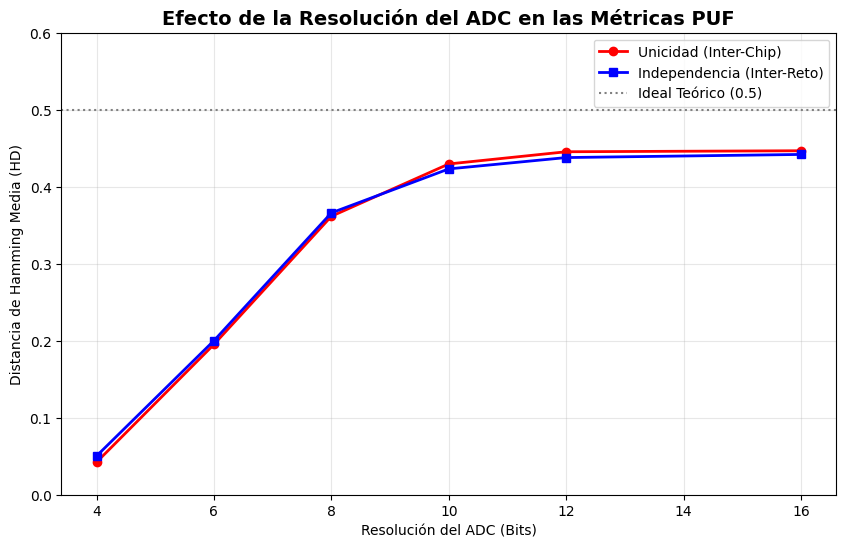

--------------------------------------------------
✅ Análisis completado. El 'punto dulce' de diseño está donde las curvas se estabilizan.


In [30]:
import numpy as np
import os
import math
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- 1. CONFIGURACIÓN Y FUNCIONES ---
P_MAX_GLOBAL = 1.0  
P_MIN_GLOBAL = 0.0

def cuantizar_adc(matriz, bits):
    niveles = 2**bits - 1
    matriz_norm = (matriz - P_MIN_GLOBAL) / (P_MAX_GLOBAL - P_MIN_GLOBAL + 1e-15)
    matriz_q = np.round(np.clip(matriz_norm, 0, 1) * niveles) / niveles
    return matriz_q * (P_MAX_GLOBAL - P_MIN_GLOBAL) + P_MIN_GLOBAL

def binarizar_puf_con_adc(matriz_lineal, bits_adc=8):
    matriz_q = cuantizar_adc(matriz_lineal, bits_adc)
    vector_bits_total = []
    for c in range(matriz_q.shape[1]):
        columna = 10 * np.log10(matriz_q[:, c] + 1e-12)
        n = len(columna)
        r = []
        for j in range(1, n):
            cuenta = np.sum(columna[:j] < columna[j])
            r.append(cuenta)
        for j, rj in enumerate(r):
            n_bits = math.ceil(math.log2(j + 2))
            gj = rj ^ (rj >> 1)
            vector_bits_total.append(format(gj, f"0{n_bits}b"))
    return "".join(vector_bits_total)

def calcular_hd(s1, s2):
    diffs = sum(c1 != c2 for c1, c2 in zip(s1, s2))
    return diffs / len(s1)

# --- 2. BARRIDO DE RESOLUCIÓN ---
bits_test = [4, 6, 8, 10, 12, 16]
directorio_fases = "base_datos_puf_FINAL_TESIS_FASES_8BITS" 
archivos = sorted([f for f in os.listdir(directorio_fases) if f.endswith('.npz')])

resultados_unicidad = []
resultados_independencia = []

print(f"🔍 Analizando impacto del fotodetector sobre {len(archivos)} chips...")

for b in bits_test:
    # --- A. CÁLCULO DE UNICIDAD (Mismo reto, diferentes chips) ---
    llaves_chips = []
    for f in archivos:
        data = np.load(os.path.join(directorio_fases, f))
        # Usamos el reto 0
        llave = binarizar_puf_con_adc(data['anillo'][0], bits_adc=b)
        llaves_chips.append(llave)
    
    hd_uni = [calcular_hd(llaves_chips[i], llaves_chips[j]) 
              for i in range(len(llaves_chips)) for j in range(i+1, len(llaves_chips))]
    
    # --- B. CÁLCULO DE INDEPENDENCIA (Mismo chip, diferentes retos) ---
    # Usamos el primer chip de la lista como representante
    data_c0 = np.load(os.path.join(directorio_fases, archivos[0]))
    llaves_retos = []
    for r in range(len(data_c0['anillo'])):
        llave = binarizar_puf_con_adc(data_c0['anillo'][r], bits_adc=b)
        llaves_retos.append(llave)
        
    hd_ind = [calcular_hd(llaves_retos[i], llaves_retos[j]) 
              for i in range(len(llaves_retos)) for j in range(i+1, len(llaves_retos))]

    # Guardamos medias
    m_uni = np.mean(hd_uni)
    m_ind = np.mean(hd_ind)
    resultados_unicidad.append(m_uni)
    resultados_independencia.append(m_ind)
    
    print(f" > ADC {b} bits: Unicidad = {m_uni:.4f} | Independencia = {m_ind:.4f}")

# --- 3. VISUALIZACIÓN ---
plt.figure(figsize=(10, 6))
plt.plot(bits_test, resultados_unicidad, 'o-r', lw=2, label="Unicidad (Inter-Chip)")
plt.plot(bits_test, resultados_independencia, 's-b', lw=2, label="Independencia (Inter-Reto)")

plt.axhline(0.5, color='gray', linestyle=':', label="Ideal Teórico (0.5)")


plt.title("Efecto de la Resolución del ADC en las Métricas PUF", fontweight='bold', fontsize=14)
plt.xlabel("Resolución del ADC (Bits)")
plt.ylabel("Distancia de Hamming Media (HD)")
plt.grid(alpha=0.3)
plt.legend()
plt.ylim([0.0, 0.6]) # Ajustado para ver la evolución desde 4 bits
plt.show()

print("-" * 50)
print(f"✅ Análisis completado. El 'punto dulce' de diseño está donde las curvas se estabilizan.")

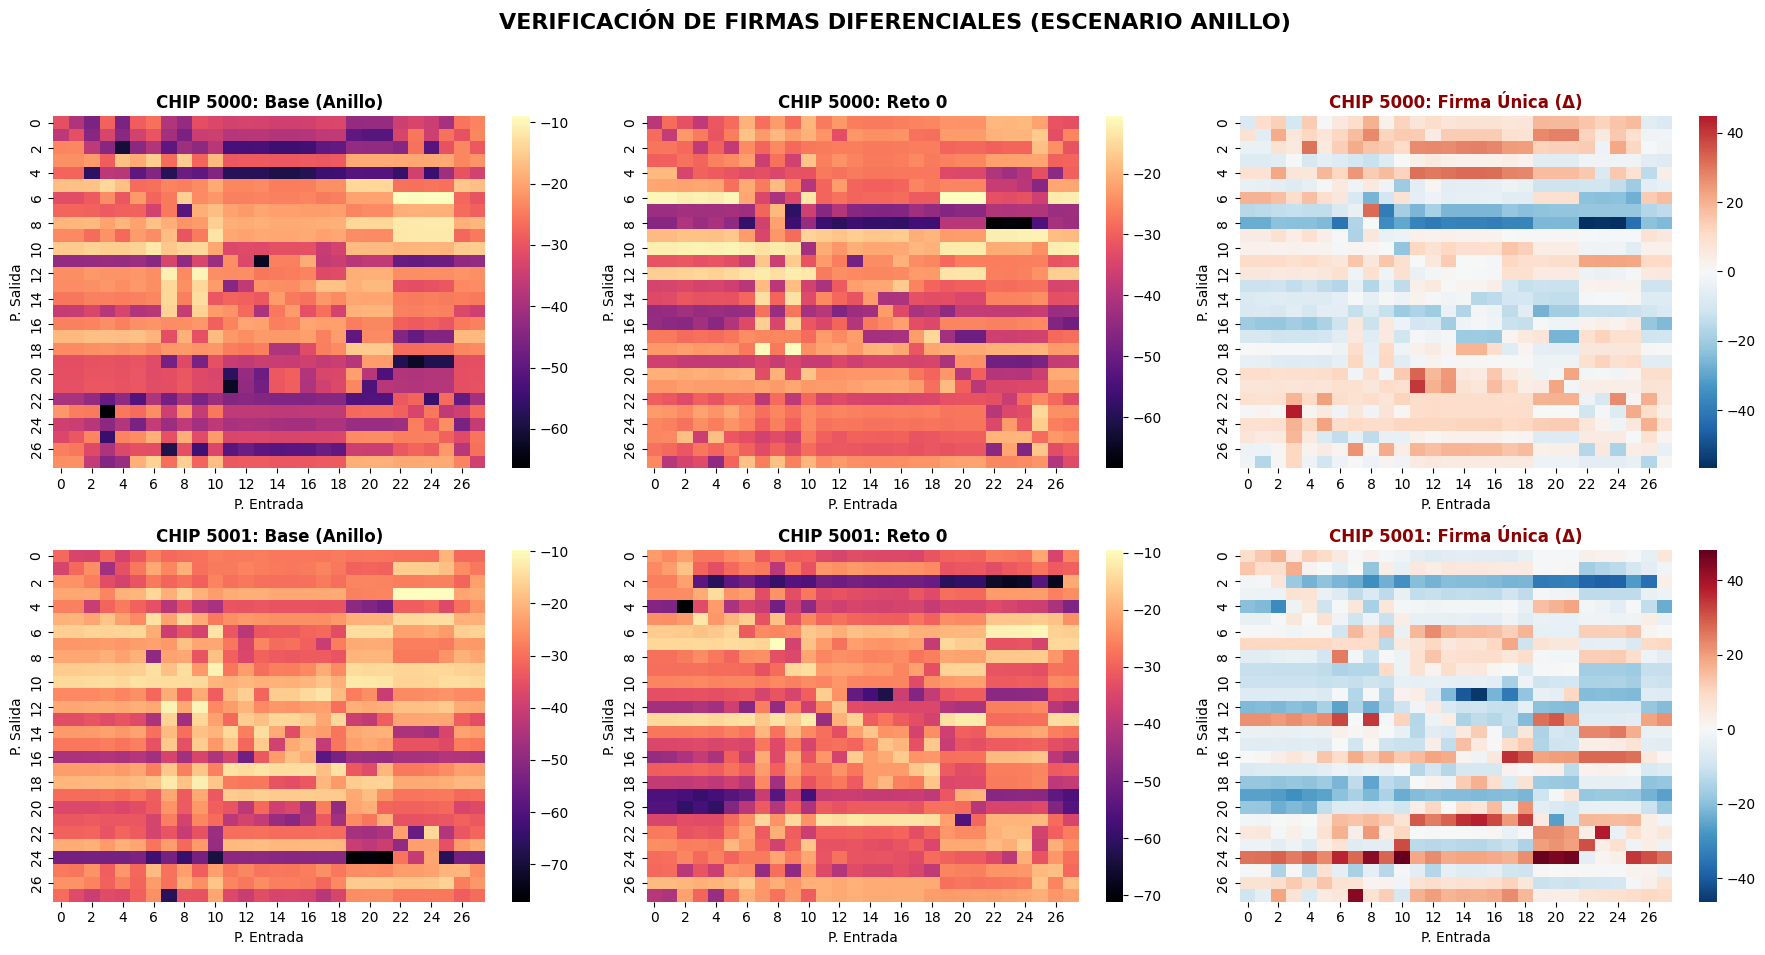

📊 Correlación entre BASES (Diseño): 0.3419
🧬 Correlación entre FIRMAS Δ (Identidad): -0.0846


In [12]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURACIÓN ---
directorio_data = "base_datos_puf_FINAL_TESIS_FASES_8BITS"
archivo_a = "chip_5000.npz"
archivo_b = "chip_5001.npz"

def procesar_firma(path):
    data = np.load(path)
    # Pasamos a escala logarítmica (dB) para resaltar variaciones
    base_db = 10 * np.log10(data['base_anillo'] + 1e-12)
    reto_db = 10 * np.log10(data['anillo'][0] + 1e-12) # Primer reto
    delta = reto_db - base_db
    return base_db, reto_db, delta, data['seed_hw']

# Cargar datos
base_a, reto_a, delta_a, id_a = procesar_firma(os.path.join(directorio_data, archivo_a))
base_b, reto_b, delta_b, id_b = procesar_firma(os.path.join(directorio_data, archivo_b))

# --- VISUALIZACIÓN ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# FILA 1: CHIP A
sns.heatmap(base_a, ax=axes[0,0], cmap='magma')
axes[0,0].set_title(f"CHIP {id_a}: Base (Anillo)", fontweight='bold')

sns.heatmap(reto_a, ax=axes[0,1], cmap='magma')
axes[0,1].set_title(f"CHIP {id_a}: Reto 0", fontweight='bold')

sns.heatmap(delta_a, ax=axes[0,2], cmap='RdBu_r', center=0)
axes[0,2].set_title(f"CHIP {id_a}: Firma Única (Δ)", fontweight='bold', color='darkred')

# FILA 2: CHIP B
sns.heatmap(base_b, ax=axes[1,0], cmap='magma')
axes[1,0].set_title(f"CHIP {id_b}: Base (Anillo)", fontweight='bold')

sns.heatmap(reto_b, ax=axes[1,1], cmap='magma')
axes[1,1].set_title(f"CHIP {id_b}: Reto 0", fontweight='bold')

sns.heatmap(delta_b, ax=axes[1,2], cmap='RdBu_r', center=0)
axes[1,2].set_title(f"CHIP {id_b}: Firma Única (Δ)", fontweight='bold', color='darkred')

# Ajustes estéticos
for ax in axes.flat:
    ax.set_xlabel("P. Entrada"); ax.set_ylabel("P. Salida")

plt.suptitle("VERIFICACIÓN DE FIRMAS DIFERENCIALES (ESCENARIO ANILLO)", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- VALIDACIÓN NUMÉRICA ---
corr_bases = np.corrcoef(base_a.flatten(), base_b.flatten())[0,1]
corr_deltas = np.corrcoef(delta_a.flatten(), delta_b.flatten())[0,1]

print(f"📊 Correlación entre BASES (Diseño): {corr_bases:.4f}")
print(f"🧬 Correlación entre FIRMAS Δ (Identidad): {corr_deltas:.4f}")

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURACIÓN ---
directorio_data = "base_datos_puf_FINAL_TESIS"
archivo_verificar = "chip_5000.npz" # Analizamos el primer chip

path = os.path.join(directorio_data, archivo_verificar)
data = np.load(path)

# 1. Recuperamos la base y los 10 retos
base_db = 10 * np.log10(data['base_anillo'] + 1e-12)
retos_raw = data['anillo'] # Tiene 10 retos

firmas_delta = []

# 2. Generamos los 10 Deltas (Firma Diferencial)
for i in range(len(retos_raw)):
    reto_db = 10 * np.log10(retos_raw[i] + 1e-12)
    delta = (reto_db - base_db ).flatten()
    firmas_delta.append(delta)

matriz_deltas = np.array(firmas_delta)

# 3. Calculamos la Correlación entre los 10 retos (10x10)
# Esto mide qué tanto se parece el Reto i al Reto j en el mismo silicio
matriz_corr_retos = np.corrcoef(matriz_deltas)

# 4. Extraer valores fuera de la diagonal para estadística
indices_sup = np.triu_indices_from(matriz_corr_retos, k=1)
valores_inter_reto = matriz_corr_retos[indices_sup]

# --- VISUALIZACIÓN ---
plt.figure(figsize=(12, 5))

# Heatmap de la matriz de correlación
plt.subplot(1, 2, 1)
sns.heatmap(matriz_corr_retos, annot=True, cmap='YlGnBu', vmin=0, vmax=1, fmt=".2f")
plt.title(f"Independencia de Retos (Chip {data['seed_hw']})\nCorrelación entre Δ de cada reto", fontweight='bold')
plt.xlabel("Índice de Reto")
plt.ylabel("Índice de Reto")

# Histograma de las correlaciones
plt.subplot(1, 2, 2)
sns.histplot(valores_inter_reto, kde=True, color='forestgreen')
plt.axvline(np.mean(valores_inter_reto), color='red', linestyle='--', label=f'Media: {np.mean(valores_inter_reto):.4f}')
plt.title("Distribución de Correlación Inter-Reto", fontweight='bold')
plt.xlabel("Coeficiente de Correlación (Pearson)")
plt.legend()

plt.tight_layout()
plt.show()

print("-" * 50)
print(f"📊 RESULTADO DE INDEPENDENCIA (DIFUSIÓN):")
print(f" > Correlación Media entre retos: {np.mean(valores_inter_reto):.4f}")
print(f" > Valor Máximo de similitud:    {np.max(valores_inter_reto):.4f}")
print("-" * 50)

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURACIÓN ---
directorio_data = "base_datos_puf_FINAL_TESIS"
archivo_verificar = "chip_5000.npz" 

path = os.path.join(directorio_data, archivo_verificar)
data = np.load(path)

# 1. Recuperamos los 10 retos (sin usar la base)
retos_raw = data['anillo'] # Array de (10, 28, 28)
firmas_raw = []

print(f"📊 Analizando correlación bruta (Raw dB) para el Chip {data['seed_hw']}...")

# 2. Convertimos cada reto a dB y aplanamos
for i in range(len(retos_raw)):
    # Convertimos a dB directamente
    reto_db = 10 * np.log10(retos_raw[i] + 1e-12)
    firmas_raw.append(reto_db.flatten())

matriz_firmas = np.array(firmas_raw) # (10 retos x 784 puntos)

# 3. Calculamos la Matriz de Correlación de Pearson (10x10)
# Mide la similitud entre el Reto i y el Reto j directamente
matriz_corr_raw = np.corrcoef(matriz_firmas)

# 4. Extraer valores de la diagonal superior
indices_sup = np.triu_indices_from(matriz_corr_raw, k=1)
valores_raw = matriz_corr_raw[indices_sup]

# --- VISUALIZACIÓN ---
plt.figure(figsize=(14, 6))

# Heatmap: Similitud estructural bruta
plt.subplot(1, 2, 1)
sns.heatmap(matriz_corr_raw, annot=True, cmap='viridis', vmin=0, vmax=1, fmt=".3f")
plt.title(f"Matriz de Correlación RAW (Chip {data['seed_hw']})\nSin Firma Diferencial", fontweight='bold')
plt.xlabel("Índice de Reto")
plt.ylabel("Índice de Reto")

# Histograma: Distribución de la similitud
plt.subplot(1, 2, 2)
sns.histplot(valores_raw, kde=True, color='darkblue', bins=15)
plt.axvline(np.mean(valores_raw), color='red', linestyle='--', label=f'Media: {np.mean(valores_raw):.4f}')
plt.title("Distribución de Correlación Inter-Reto (Bruta)", fontweight='bold')
plt.xlabel("Coeficiente de Correlación")
plt.legend()

plt.tight_layout()
plt.show()

print("-" * 50)
print(f"📈 RESULTADOS DE ANALISIS RAW (SIN RESTA):")
print(f" > Correlación Media: {np.mean(valores_raw):.4f}")
print(f" > Valor Mínimo:      {np.min(valores_raw):.4f}")
print(f" > Valor Máximo:      {np.max(valores_raw):.4f}")
print("-" * 50)

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# --- CONFIGURACIÓN ---
directorio_data = "base_datos_puf_FINAL_TESIS"
archivo_chip = "chip_5000.npz"
path = os.path.join(directorio_data, archivo_chip)

# 1. Carga de datos y preparación de la base
data = np.load(path)
base_db = 10 * np.log10(data['base_anillo'] + 1e-12)
retos_raw = data['anillo']  # Array de (10, 28, 28)
id_hw = data['seed_hw']

# 2. Configuración de la figura (2 filas, 5 columnas)
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print(f"🖼️ Generando galería de firmas para el Chip {id_hw}...")

for i in range(10):
    # Calcular Delta para el reto i
    reto_db = 10 * np.log10(retos_raw[i] + 1e-12)
    delta = reto_db - base_db
    
    # Visualización
    sns.heatmap(delta, ax=axes[i], cmap='RdBu_r', center=0, 
                cbar=(i == 9), # Solo mostrar barra de color en el último
                xticklabels=False, yticklabels=False)
    
    axes[i].set_title(f"RETO {i}", fontweight='bold', fontsize=12)
    
    # Calcular correlación con el reto anterior para control interno
    if i > 0:
        prev_reto_db = 10 * np.log10(retos_raw[i-1] + 1e-12)
        prev_delta = prev_reto_db - base_db
        corr = np.corrcoef(delta.flatten(), prev_delta.flatten())[0,1]
        axes[i].set_xlabel(f"Corr con R{i-1}: {corr:.3f}", fontsize=10)

plt.suptitle(f"DINÁMICA DE RETOS: 10 Firmas Diferenciales (Δ) del Chip {id_hw}\n(Cada imagen es una llave criptográfica potencial)", 
             fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

📦 Analizando 10 chips con binarización por columnas...


Binarizando para Unicidad: 100%|███████████████████████████████████████████████████████| 10/10 [00:00<00:00, 63.40it/s]


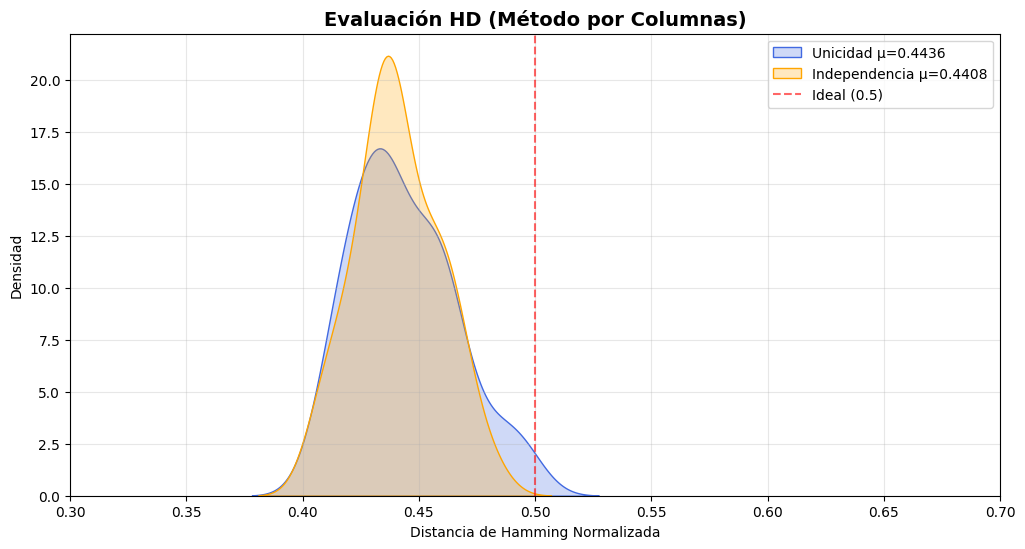

--------------------------------------------------
📊 RESULTADOS FINALES (Binarización por Columnas):
 > UNICIDAD MEDIA:      0.4436
 > INDEPENDENCIA MEDIA: 0.4408
 > LONGITUD DE LLAVE:   3052 bits
--------------------------------------------------


In [16]:
import numpy as np
import os
import math
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- 1. FUNCIONES DE BINARIZACIÓN (LEHMER + GRAY) ---

def binarizar_puf_lehmer_por_columnas(matriz_lineal):
    """Binariza la matriz procesando cada columna (puerto de entrada) de forma independiente."""
    vector_bits_total = []
    
    # Procesamos cada columna (experimento de inyección individual)
    for c in range(matriz_lineal.shape[1]):
        columna = 10 * np.log10(matriz_lineal[:, c] + 1e-12)
        n = len(columna)
        
        # Coeficientes de Lehmer para esta columna (N=28)
        r = []
        for j in range(1, n):
            # Ranking relativo dentro de la misma inyección
            cuenta = np.sum(columna[:j] < columna[j])
            r.append(cuenta)

        # Gray + Bitstring para esta columna
        for j, rj in enumerate(r):
            n_bits = math.ceil(math.log2(j + 2))
            gj = rj ^ (rj >> 1)
            vector_bits_total.append(format(gj, f"0{n_bits}b"))
    
    return "".join(vector_bits_total)

def calcular_hd(s1, s2):
    """Distancia de Hamming normalizada."""
    diffs = sum(c1 != c2 for c1, c2 in zip(s1, s2))
    return diffs / len(s1)

# --- 2. CARGA Y PROCESAMIENTO ---
directorio_data = "base_datos_puf_FINAL_TESIS_FASES_4BITS"
archivos = sorted([f for f in os.listdir(directorio_data) if f.endswith('.npz')])

print(f"📦 Analizando {len(archivos)} chips con binarización por columnas...")

llaves_inter_chip = [] 
llaves_inter_reto = [] 

# Procesamos para Unicidad (Inter-Chip) usando el método de columnas
for f in tqdm(archivos, desc="Binarizando para Unicidad"):
    data = np.load(os.path.join(directorio_data, f))
    # Cambiamos aquí: usamos la nueva función y ya no necesitamos data['base_anillo']
    bits = binarizar_puf_lehmer_por_columnas(data['anillo'][0])
    llaves_inter_chip.append(bits)

# Procesamos para Independencia (Inter-Reto) del primer chip
data_c0 = np.load(os.path.join(directorio_data, archivos[0]))
for i in range(len(data_c0['anillo'])):
    # Cambiamos aquí también
    bits = binarizar_puf_lehmer_por_columnas(data_c0['anillo'][i])
    llaves_inter_reto.append(bits)

# --- 3. CÁLCULO DE DISTANCIAS DE HAMMING ---
hd_unicidad = [calcular_hd(llaves_inter_chip[i], llaves_inter_chip[j]) 
               for i in range(len(llaves_inter_chip)) 
               for j in range(i + 1, len(llaves_inter_chip))]

hd_independencia = [calcular_hd(llaves_inter_reto[i], llaves_inter_reto[j]) 
                    for i in range(len(llaves_inter_reto)) 
                    for j in range(i + 1, len(llaves_inter_reto))]

# --- 4. VISUALIZACIÓN ---
plt.figure(figsize=(12, 6))
sns.kdeplot(hd_unicidad, fill=True, color="royalblue", label=f"Unicidad μ={np.mean(hd_unicidad):.4f}")
sns.kdeplot(hd_independencia, fill=True, color="orange", label=f"Independencia μ={np.mean(hd_independencia):.4f}")

plt.axvline(0.5, color='red', linestyle='--', alpha=0.6, label="Ideal (0.5)")
plt.title("Evaluación HD (Método por Columnas)", fontweight='bold', fontsize=14)
plt.xlabel("Distancia de Hamming Normalizada")
plt.ylabel("Densidad")
plt.xlim([0.3, 0.7])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("-" * 50)
print(f"📊 RESULTADOS FINALES (Binarización por Columnas):")
print(f" > UNICIDAD MEDIA:      {np.mean(hd_unicidad):.4f}")
print(f" > INDEPENDENCIA MEDIA: {np.mean(hd_independencia):.4f}")
print(f" > LONGITUD DE LLAVE:   {len(llaves_inter_chip[0])} bits")
print("-" * 50)

In [ ]:
import numpy as np
import os
import math
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- 1. FUNCIÓN DE CUANTIZACIÓN (SIMULACIÓN ADC) ---
def cuantizar(matriz, bits):
    """Simula la resolución de un ADC de N bits."""
    if bits is None: return matriz
    
    # Normalizamos la matriz al rango [0, 1] para aplicar la cuantización
    m_min, m_max = matriz.min(), matriz.max()
    matriz_norm = (matriz - m_min) / (m_max - m_min + 1e-15)
    
    # Discretizamos en 2^bits niveles
    niveles = 2**bits - 1
    matriz_q = np.round(matriz_norm * niveles) / niveles
    
    # Devolvemos a la escala original
    return matriz_q * (m_max - m_min) + m_min

# --- 2. BINARIZACIÓN ADAPTADA ---
def binarizar_puf_lehmer_adc(matriz_lineal, bits_adc=None):
    """Binariza aplicando primero una resolución de ADC específica."""
    # Simulamos el ADC antes de cualquier procesamiento
    matriz_q = cuantizar(matriz_lineal, bits_adc)
    
    vector_bits_total = []
    for c in range(matriz_q.shape[1]):
        # El logaritmo se aplica sobre la señal ya cuantizada
        columna = 10 * np.log10(matriz_q[:, c] + 1e-12)
        n = len(columna)
        r = []
        for j in range(1, n):
            # Ranking de Lehmer
            cuenta = np.sum(columna[:j] < columna[j])
            r.append(cuenta)

        for j, rj in enumerate(r):
            n_bits = math.ceil(math.log2(j + 2))
            gj = rj ^ (rj >> 1)
            vector_bits_total.append(format(gj, f"0{n_bits}b"))
            
    return "".join(vector_bits_total)

def calcular_hd(s1, s2):
    diffs = sum(c1 != c2 for c1, c2 in zip(s1, s2))
    return diffs / len(s1)

# --- 3. BARRIDO DE RESOLUCIÓN ---
resoluciones = [4, 6, 8, 10, 12, 16] # Bits del ADC
unicidad_por_res = []

directorio_data = "base_datos_puf_FINAL_TESIS"
archivos = sorted([f for f in os.listdir(directorio_data) if f.endswith('.npz')])

print("📉 Iniciando barrido de resolución de ADC...")

for b in resoluciones:
    llaves = []
    for f in archivos:
        data = np.load(os.path.join(directorio_data, f))
        # Binarizamos cada chip con la resolución actual 'b'
        bits = binarizar_puf_lehmer_adc(data['anillo'][0], bits_adc=b)
        llaves.append(bits)
    
    # Calculamos HD media (Unicidad) para esta resolución
    distancias = [calcular_hd(llaves[i], llaves[j]) 
                  for i in range(len(llaves)) for j in range(i+1, len(llaves))]
    unicidad_por_res.append(np.mean(distancias))
    print(f" > Resolución {b} bits: Unicidad = {np.mean(distancias):.4f}")

# --- 4. VISUALIZACIÓN ---
plt.figure(figsize=(8, 5))
plt.plot(resoluciones, unicidad_por_res, 'o-', color='crimson', linewidth=2, markersize=8)
plt.axhline(0.4415, color='gray', linestyle='--', label='Resolución Infinita (Original)')
plt.title("Impacto de la Resolución del Fotodetector (ADC)", fontweight='bold')
plt.xlabel("Bits del ADC (Resolución)")
plt.ylabel("Unicidad Media (HD)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [ ]:
import numpy as np
import os
import math
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- 1. FUNCIÓN DE BINARIZACIÓN AVANZADA (FACTORADIC) ---

def binarizar_puf_lehmer_factoradic(matriz_lineal):
    """
    Binariza la matriz usando el Sistema de Numeración Factorial.
    Convierte el ranking de cada columna en un único entero denso.
    """
    vector_bits_total = []
    n_puertos = matriz_lineal.shape[0] # 28
    
    # Calculamos cuántos bits necesitamos para representar todas las permutaciones de 28 puertos
    # log2(28!) ≈ 97.9 -> Usamos 98 bits para asegurar longitud fija por columna
    n_bits_por_columna = math.ceil(math.log2(math.factorial(n_puertos)))
    
    for c in range(matriz_lineal.shape[1]):
        columna = 10 * np.log10(matriz_lineal[:, c] + 1e-12)
        
        # 1. Extraer coeficientes de Lehmer (rj)
        r = []
        for j in range(1, n_puertos):
            cuenta = np.sum(columna[:j] < columna[j])
            r.append(cuenta)
        
        # 2. Convertir vector de Lehmer a un único número decimal (Factoradic)
        # Valor = r1*1! + r2*2! + ... + r27*27!
        valor_decimal = 0
        for j, rj in enumerate(r):
            valor_decimal += rj * math.factorial(j + 1)
            
        # 3. Convertir ese número a binario con longitud fija (denso, sin ceros de relleno entre bits)
        bits_columna = format(valor_decimal, f"0{n_bits_por_columna}b")
        vector_bits_total.append(bits_columna)
    
    return "".join(vector_bits_total)

def calcular_hd(s1, s2):
    """Distancia de Hamming normalizada."""
    diffs = sum(c1 != c2 for c1, c2 in zip(s1, s2))
    return diffs / len(s1)

# --- 2. CARGA Y PROCESAMIENTO ---
directorio_data = "base_datos_puf_FINAL_TESIS"
archivos = sorted([f for f in os.listdir(directorio_data) if f.endswith('.npz')])

print(f"📦 Analizando {len(archivos)} chips con método FACTORADIC...")

llaves_inter_chip = [] 
llaves_inter_reto = [] 

# Unicidad (Inter-Chip)
for f in tqdm(archivos, desc="Binarizando Unicidad"):
    data = np.load(os.path.join(directorio_data, f))
    bits = binarizar_puf_lehmer_factoradic(data['anillo'][0])
    llaves_inter_chip.append(bits)

# Independencia (Inter-Reto)
data_c0 = np.load(os.path.join(directorio_data, archivos[0]))
for i in range(len(data_c0['anillo'])):
    bits = binarizar_puf_lehmer_factoradic(data_c0['anillo'][i])
    llaves_inter_reto.append(bits)

# --- 3. CÁLCULO DE DISTANCIAS DE HAMMING ---
hd_unicidad = [calcular_hd(llaves_inter_chip[i], llaves_inter_chip[j]) 
               for i in range(len(llaves_inter_chip)) 
               for j in range(i + 1, len(llaves_inter_chip))]

hd_independencia = [calcular_hd(llaves_inter_reto[i], llaves_inter_reto[j]) 
                    for i in range(len(llaves_inter_reto)) 
                    for j in range(i + 1, len(llaves_inter_reto))]

# --- 4. VISUALIZACIÓN ---
plt.figure(figsize=(12, 6))
sns.kdeplot(hd_unicidad, fill=True, color="forestgreen", label=f"Unicidad Factoradic μ={np.mean(hd_unicidad):.4f}")
sns.kdeplot(hd_independencia, fill=True, color="darkorange", label=f"Independencia Factoradic μ={np.mean(hd_independencia):.4f}")

plt.axvline(0.5, color='red', linestyle='--', alpha=0.6, label="Ideal (0.5)")
plt.title("Evaluación HD: Empaquetamiento Denso (Factoradic)", fontweight='bold', fontsize=14)
plt.xlabel("Distancia de Hamming Normalizada")
plt.ylabel("Densidad")
plt.xlim([0.3, 0.7])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("-" * 50)
print(f"📊 RESULTADOS FINALES (Método Factoradic):")
print(f" > UNICIDAD MEDIA:      {np.mean(hd_unicidad):.4f}")
print(f" > INDEPENDENCIA MEDIA: {np.mean(hd_independencia):.4f}")
print(f" > LONGITUD DE LLAVE:   {len(llaves_inter_chip[0])} bits")
print("-" * 50)

In [ ]:
import numpy as np
import os
import math
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- 1. FUNCIÓN DE BINARIZACIÓN POR MEDIANA (ADAPTATIVA) ---

def binarizar_puf_mediana(matriz_lineal):
    """
    Binarización por Mediana:
    Cada bit se obtiene comparando la potencia del puerto con la mediana de su propia columna.
    Garantiza un peso de bit de 0.5 y maximiza la Unicidad al eliminar el modo común de la malla.
    """
    vector_bits_total = []
    
    # Procesamos cada columna (puerto de entrada) de forma independiente
    for c in range(matriz_lineal.shape[1]):
        columna = matriz_lineal[:, c]
        
        # Calculamos la mediana de los puertos para esta inyección específica
        mediana = np.median(columna)
        
        # Generamos un bit por cada puerto de salida
        for valor in columna:
            # Si el valor es mayor que la mediana -> 1, si no -> 0
            # Esto asegura que el 50% de la respuesta sean unos
            bit = "1" if valor > mediana else "0"
            vector_bits_total.append(bit)
            
    return "".join(vector_bits_total)

def calcular_hd(s1, s2):
    """Distancia de Hamming normalizada."""
    diffs = sum(c1 != c2 for c1, c2 in zip(s1, s2))
    return diffs / len(s1)

# --- 2. CARGA Y PROCESAMIENTO ---
directorio_data = "base_datos_puf_FINAL_TESIS"
archivos = sorted([f for f in os.listdir(directorio_data) if f.endswith('.npz')])

print(f"📦 Analizando {len(archivos)} chips con MÉTODO DE MEDIANA...")

llaves_inter_chip = [] 
llaves_inter_reto = [] 

# Procesamos para Unicidad (Inter-Chip)
for f in tqdm(archivos, desc="Binarizando Unicidad"):
    data = np.load(os.path.join(directorio_data, f))
    # Usamos la binarización por mediana sobre el primer reto
    bits = binarizar_puf_mediana(data['anillo'][0])
    llaves_inter_chip.append(bits)

# Procesamos para Independencia (Inter-Reto) del primer chip
data_c0 = np.load(os.path.join(directorio_data, archivos[0]))
for i in range(len(data_c0['anillo'])):
    bits = binarizar_puf_mediana(data_c0['anillo'][i])
    llaves_inter_reto.append(bits)

# --- 3. CÁLCULO DE DISTANCIAS DE HAMMING ---
hd_unicidad = [calcular_hd(llaves_inter_chip[i], llaves_inter_chip[j]) 
               for i in range(len(llaves_inter_chip)) 
               for j in range(i + 1, len(llaves_inter_chip))]

hd_independencia = [calcular_hd(llaves_inter_reto[i], llaves_inter_reto[j]) 
                    for i in range(len(llaves_inter_reto)) 
                    for j in range(i + 1, len(llaves_inter_reto))]

# --- 4. VISUALIZACIÓN ---
plt.figure(figsize=(12, 6))
sns.kdeplot(hd_unicidad, fill=True, color="royalblue", label=f"Unicidad (Mediana) μ={np.mean(hd_unicidad):.4f}")
sns.kdeplot(hd_independencia, fill=True, color="darkorange", label=f"Independencia (Mediana) μ={np.mean(hd_independencia):.4f}")

plt.axvline(0.5, color='red', linestyle='--', alpha=0.8, label="Ideal (0.5)")
plt.title("Evaluación HD: Binarización Adaptativa por Umbral de Mediana", fontweight='bold', fontsize=14)
plt.xlabel("Distancia de Hamming Normalizada")
plt.ylabel("Densidad")
plt.xlim([0.3, 0.7])
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("-" * 50)
print(f"📊 RESULTADOS FINALES (Método Mediana):")
print(f" > UNICIDAD MEDIA:      {np.mean(hd_unicidad):.4f}")
print(f" > INDEPENDENCIA MEDIA: {np.mean(hd_independencia):.4f}")
print(f" > LONGITUD DE LLAVE:   {len(llaves_inter_chip[0])} bits")
print("-" * 50)

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# --- 1. FUNCIÓN DE EXTRACCIÓN DE VECTOR ANALÓGICO ---
def obtener_vector_db(matriz_lineal):
    # Convertimos a dB y aplanamos a un vector de 784 elementos (28x28)
    vector_db = 10 * np.log10(matriz_lineal + 1e-12)
    # Opcional: Normalización Z-score para comparar "formas" y no potencias globales
    # return (vector_db - np.mean(vector_db)) / np.std(vector_db)
    return vector_db.flatten()

def calcular_l2(v1, v2):
    """Calcula la norma L2 (Euclídea) entre dos vectores"""
    return np.linalg.norm(v1 - v2)

# --- 2. CARGA Y PROCESAMIENTO ---
directorio_data = "base_datos_puf_FINAL_TESIS"
archivos = sorted([f for f in os.listdir(directorio_data) if f.endswith('.npz')])

print(f"📦 Analizando Distancia Euclídea en {len(archivos)} chips...")

vectores_inter_chip = [] # Reto 0 de cada chip
vectores_inter_reto = [] # Todos los retos del primer chip

# Procesamos para Unicidad (Inter-Chip)
for f in tqdm(archivos, desc="Procesando Inter-Chip"):
    data = np.load(os.path.join(directorio_data, f))
    v = obtener_vector_db(data['anillo'][0])
    vectores_inter_chip.append(v)

# Procesamos para Independencia (Inter-Reto)
data_c0 = np.load(os.path.join(directorio_data, archivos[0]))
for i in range(len(data_c0['anillo'])):
    v = obtener_vector_db(data_c0['anillo'][i])
    vectores_inter_reto.append(v)

# --- 3. CÁLCULO DE DISTANCIAS ---
l2_unicidad = []
for i in range(len(vectores_inter_chip)):
    for j in range(i + 1, len(vectores_inter_chip)):
        l2_unicidad.append(calcular_l2(vectores_inter_chip[i], vectores_inter_chip[j]))

l2_independencia = []
for i in range(len(vectores_inter_reto)):
    for j in range(i + 1, len(vectores_inter_reto)):
        l2_independencia.append(calcular_l2(vectores_inter_reto[i], vectores_inter_reto[j]))

# --- 4. VISUALIZACIÓN ---
plt.figure(figsize=(12, 6))

sns.kdeplot(l2_unicidad, fill=True, color="darkblue", label=f"L2 Inter-Chip (Unicidad) μ={np.mean(l2_unicidad):.2f}")
sns.kdeplot(l2_independencia, fill=True, color="darkorange", label=f"L2 Inter-Reto (Independencia) μ={np.mean(l2_independencia):.2f}")

plt.title("Análisis de Separación Vectorial (Norma $L_2$)", fontweight='bold', fontsize=14)
plt.xlabel("Distancia Euclídea (Vectores dB)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("-" * 50)
print(f"📊 RESULTADOS DE MÉTRICA EUCLÍDEA:")
print(f" > L2 UNICIDAD MEDIA:      {np.mean(l2_unicidad):.4f}")
print(f" > L2 INDEPENDENCIA MEDIA: {np.mean(l2_independencia):.4f}")
print(f" > RATIO UNICIDAD/INDEP:   {np.mean(l2_unicidad)/np.mean(l2_independencia):.4f}")
print("-" * 50)

In [ ]:
import numpy as np
import math
import hashlib
# Asegúrate de tener instalado bchlib (pip install bchlib)
import bchlib 

def binarización(valores):
    valores = list(valores)
    n = len(valores)
    r = []
    # Coeficientes de Lehmer: O(n^2)
    # Para 1600 puntos, esto hará ~2.5 millones de comparaciones. 
    # Es asumible, pero tardará un par de segundos por reto.
    for j in range(1, n): 
        cuenta = 0
        for i in range(j):  
            if valores[j] > valores[i]:
                cuenta += 1
        r.append(cuenta)

    def a_gray(x):
        return x ^ (x >> 1)

    bloques_gray = []
    for j in range(1, len(r) + 1):    
        rj = r[j-1]  
        # Cálculo de bits necesarios para el coeficiente j-ésimo
        bits = math.ceil(math.log2(j + 1))       
        gj = a_gray(rj)
        bloques_gray.append(format(gj, f"0{bits}b")) 
    
    return "".join(bloques_gray), r, bloques_gray

def string_a_bits(respuesta):
    return [int(c) for c in respuesta]

def rellenar_a_byte(bits):
    # Asegura que la longitud sea múltiplo de 8 para bchlib
    bits = list(bits) # Asegurar que es lista para poder concatenar
    resto = len(bits) % 8
    if resto != 0:
        bits += [1] * (8 - resto)
    return bits

def bits_to_bytes_local(bits):
    out = bytearray()
    for i in range(0, len(bits), 8):
        byte = 0
        for bit in bits[i:i+8]:
            byte = (byte << 1) | bit
        out.append(byte)
    return bytes(out)

def bytes_to_bits(data):
    out = []
    for byte in data:
        for i in range(7, -1, -1):
            out.append((byte >> i) & 1)
    return out

def xor_bits(a, b):
    return [x ^ y for x, y in zip(a, b)]

def hamming_distance(a, b):
    # Distancia de Hamming entera
    return sum(x ^ y for x, y in zip(a, b))

# --- FUZZY EXTRACTOR Y BCH ---

def puf_enrollment(bits, bch_obj, n_bloques=64):
    """Genera el Helper Data (paridad)"""
    # Importante: np.array_split puede devolver arrays de tamaños ligeramente distintos
    fragmentos = np.array_split(bits, n_bloques)
    helper_data_list = []
    for frag in fragmentos:
        # Rellenamos cada fragmento antes de convertir a bytes
        data_bytes = bits_to_bytes_local(rellenar_a_byte(list(frag)))
        paridad = bch_obj.encode(data_bytes)
        helper_data_list.append(paridad)
    return helper_data_list

def puf_reconstruction(bits_ruidosos, helper_data_list, bch_obj):
    """Corrige errores usando Helper Data"""
    n_bloques = len(helper_data_list)
    fragmentos = np.array_split(bits_ruidosos, n_bloques)
    bloques_corregidos = []
    errores_totales = 0
    
    for i in range(n_bloques):
        # Convertimos fragmento ruidoso a bytearray para permitir corrección in-place
        data_r = bytearray(bits_to_bytes_local(rellenar_a_byte(list(fragmentos[i]))))
        paridad = bytearray(helper_data_list[i])
       
        # decode devuelve el número de errores corregidos o -1 si falla
        n_err = bch_obj.decode(data_r, paridad)
        if n_err >= 0:
            bch_obj.correct(data_r, paridad)
            errores_totales += n_err
        
        bloques_corregidos.append(data_r)
        
    return b"".join(bloques_corregidos), errores_totales

def generar_hash_sha256(datos_bytes):
    return hashlib.sha256(datos_bytes).hexdigest()

def binarización_optimizada(valores):
    valores = np.asarray(valores)
    n = len(valores)
    
    # 1. Cálculo vectorizado de Coeficientes de Lehmer
    # Creamos una matriz de comparación (n, n)
    # comp[j, i] es True si valores[j] > valores[i]
    comp = valores[:, np.newaxis] > valores[np.newaxis, :]
    
    # Solo nos interesan los elementos donde i < j (triángulo inferior)
    mask = np.tril(np.ones((n, n), dtype=bool), k=-1)
    
    # Sumamos las comparaciones válidas por fila y quitamos el primer elemento (j=0 no tiene i<j)
    r = np.sum(comp & mask, axis=1)[1:].astype(int)
    
    # 2. Convertir a Gray y String (Esta parte es más difícil de vectorizar 
    # pero al ser n=1600, el bucle simple ya es rápido)
    def a_gray(x):
        return x ^ (x >> 1)
    
    bloques_gray = []
    # Pre-calculamos los bits necesarios para cada posición j
    # j va de 1 a n-1, r tiene longitud n-1
    for idx, rj in enumerate(r):
        j_actual = idx + 1
        bits = math.ceil(math.log2(j_actual + 1))
        gj = a_gray(rj)
        bloques_gray.append(format(gj, f"0{bits}b"))
        
    return "".join(bloques_gray), r, bloques_gray

In [ ]:
import numpy as np
import os
import math
import matplotlib.pyplot as plt
import bchlib
import hashlib
from tqdm import tqdm

# --- 1. CONFIGURACIÓN DEL EXPERIMENTO ---
# SNR alto = poco ruido | SNR bajo = mucho ruido
snr_axis_db = np.arange(45, 20, -1.0) 
sigmas_ruido = 10**(-snr_axis_db / 20) 

n_chips_test = 20  # Probamos con una submuestra para ir rápido
n_retos_por_chip = 3
n_intentos_ruidosos = 10 # Cuántas veces probamos cada reto con ruido

# Configuración BCH (t=30 errores corregibles por bloque)
BCH_T = 30
BCH_M = 13
bch = bchlib.BCH(t=BCH_T, m=BCH_M)

directorio_data = "base_datos_puf_FINAL_TESIS"
archivos = sorted([f for f in os.listdir(directorio_data) if f.endswith('.npz')])[:n_chips_test]

# --- 2. MOTOR DE VALIDACIÓN (FUZZY EXTRACTOR) ---
resultados_exito = np.zeros(len(snr_axis_db))

print(f"🚀 Iniciando Test de Fiabilidad (Fuzzy Extractor)...")


for idx_snr, s_ruido in enumerate(sigmas_ruido):
    exitos_totales = 0
    total_pruebas = 0
    
    for f_name in archivos:
        data = np.load(os.path.join(directorio_data, f_name))
        # Usamos los retos almacenados como firmas "limpias" de referencia
        for r_idx in range(n_retos_por_chip):
            # A. FIRMA LIMPIA (Día 1 - Enrollment)
            firma_raw = 10 * np.log10(data['anillo'][r_idx] + 1e-12).flatten()
            # Normalización Z-Score para que el ruido sea relativo a la potencia
            huella_ref = (firma_raw - np.mean(firma_raw)) / np.std(firma_raw)
            
            # Generar Bits y Helper Data
            bits_ref_str, _, _ = binarización_optimizada(huella_ref)
            bits_ref_lista = [int(b) for b in bits_ref_str]
            helper_data = puf_enrollment(bits_ref_lista, bch)
            
            # Generar Hash de referencia
            bloques_ref = np.array_split(bits_ref_lista, 64)
            bytes_ref = b"".join([bits_to_bytes_local(rellenar_a_byte(list(f))) for f in bloques_ref])
            hash_ref = hashlib.sha256(bytes_ref).hexdigest()

            # B. RECONSTRUCCIÓN CON RUIDO (Día 2 - Autenticación)
            for _ in range(n_intentos_ruidosos):
                # Añadir ruido Gaussiano a la huella normalizada
                ruido = np.random.normal(0, s_ruido, huella_ref.shape)
                huella_ruidosa = huella_ref + ruido
                
                # Binarizar versión ruidosa
                bits_ruidosos_str, _, _ = binarización_optimizada(huella_ruidosa)
                bits_ruidosos_lista = [int(b) for b in bits_ruidosos_str]
                
                total_pruebas += 1
                try:
                    # Intentar corregir errores con BCH
                    bytes_corr, _ = puf_reconstruction(bits_ruidosos_lista, helper_data, bch)
                    # Verificar si el Hash coincide
                    if hashlib.sha256(bytes_corr).hexdigest() == hash_ref:
                        exitos_totales += 1
                except:
                    pass
    
    porcentaje_exito = (exitos_totales / total_pruebas) * 100
    resultados_exito[idx_snr] = porcentaje_exito
    print(f"SNR: {snr_axis_db[idx_snr]} dB | Éxito: {porcentaje_exito:.1f}%")

# --- 3. GRÁFICA DE WATERFALL ---
plt.figure(figsize=(10, 6))
plt.plot(snr_axis_db, resultados_exito, 'o-', color='#2c3e50', linewidth=2.5, markersize=8)
plt.fill_between(snr_axis_db, resultados_exito, color='#3498db', alpha=0.3)

plt.axhline(100, color='green', linestyle='--', alpha=0.5, label="Perfecto")
plt.axvline(15, color='red', linestyle=':', label="Límite Operativo Típico")

plt.title('Robustez del Sistema: Tasa de Reconstrucción de Llave', fontsize=14, fontweight='bold')
plt.xlabel('Relación Señal-Ruido (SNR en dB) [Más ruido →]', fontsize=12)
plt.ylabel('Probabilidad de Éxito (Matching Hash) %', fontsize=12)
plt.gca().invert_xaxis() # Invertimos para ver el "Waterfall"
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

In [ ]:
import numpy as np
import os
import math
import matplotlib.pyplot as plt
import bchlib
import hashlib
from tqdm import tqdm

# --- 1. FUNCIONES DE CUANTIZACIÓN Y BINARIZACIÓN ---

def cuantizar_matriz(matriz, n_bits):
    """Simula un ADC de N bits sobre la matriz de potencia."""
    m_min, m_max = np.min(matriz), np.max(matriz)
    m_norm = (matriz - m_min) / (m_max - m_min + 1e-12)
    niveles = 2**n_bits - 1
    m_digital = np.round(m_norm * niveles) / niveles
    return m_min + m_digital * (m_max - m_min)

def binarizar_puf_lehmer_adc_columnas(matriz_lineal, n_bits=None):
    """
    Binarización por columnas con simulación de ADC en el dominio lineal.
    """
    if n_bits is not None:
        m_proc = cuantizar_matriz(matriz_lineal, n_bits)
    else:
        m_proc = matriz_lineal
    
    vector_bits_total = []
    for c in range(m_proc.shape[1]):
        columna_db = 10 * np.log10(m_proc[:, c] + 1e-12)
        n = len(columna_db)
        r = [np.sum(columna_db[:j] < columna_db[j]) for j in range(1, n)]
        for j, rj in enumerate(r):
            n_bits_block = math.ceil(math.log2(j + 2))
            gj = rj ^ (rj >> 1)
            vector_bits_total.append(format(gj, f"0{n_bits_block}b"))
    
    return "".join(vector_bits_total)

def calcular_hd(s1, s2):
    diffs = sum(c1 != c2 for c1, c2 in zip(s1, s2))
    return diffs / len(s1)

# --- 2. CONFIGURACIÓN DEL EXPERIMENTO ---

directorio_data = "base_datos_puf_FINAL_TESIS"
archivos = sorted([f for f in os.listdir(directorio_data) if f.endswith('.npz')])[:30]

bits_rango = [2, 4, 6, 8, 10, 12]
snr_test = 10.0 
sigma_ruido = 10**(-snr_test / 20)

bch = bchlib.BCH(t=30, m=13)

resultados_unicidad = []
resultados_fiabilidad = []

print(f"🚀 Analizando impacto de la resolución del fotodetector...")

for nb in bits_rango:
    # A. UNICIDAD (INTER-CHIP)
    llaves_chips = []
    for f in archivos:
        data = np.load(os.path.join(directorio_data, f))
        bits = binarizar_puf_lehmer_adc_columnas(data['anillo'][0], n_bits=nb)
        llaves_chips.append(bits)
    
    hds = [calcular_hd(llaves_chips[i], llaves_chips[j]) 
           for i in range(len(llaves_chips)) for j in range(i + 1, len(llaves_chips))]
    
    mean_hd = np.mean(hds)
    resultados_unicidad.append(mean_hd)

    # B. FIABILIDAD (RECONSTRUCCIÓN CON BCH)
    exitos = 0
    total_intentos = 50 
    
    for _ in range(total_intentos):
        f_rand = np.random.choice(archivos)
        data = np.load(os.path.join(directorio_data, f_rand))
        
        # Enrollment: Usamos la función de columnas actualizada
        bits_ref_str = binarizar_puf_lehmer_adc_columnas(data['anillo'][0], n_bits=nb)
        bits_ref_lista = [int(b) for b in bits_ref_str]
        
        try:
            helper_data = puf_enrollment(bits_ref_lista, bch)
            
            # Reconstrucción con ruido
            firma_raw = 10 * np.log10(data['anillo'][0] + 1e-12).flatten()
            huella_ref = (firma_raw - np.mean(firma_raw)) / np.std(firma_raw)
            ruido = np.random.normal(0, sigma_ruido, huella_ref.shape)
            huella_ruidosa_db = huella_ref + ruido
            
            # Convertimos a lineal para procesar ADC y Lehmer por columnas
            bits_ruid_str = binarizar_puf_lehmer_adc_columnas(10**(huella_ruidosa_db.reshape(28,28)/10), n_bits=nb)
            bits_ruid_lista = [int(b) for b in bits_ruid_str]
            
            _, n_err = puf_reconstruction(bits_ruid_lista, helper_data, bch)
            if n_err >= 0: exitos += 1
        except: pass

    acc = (exitos / total_intentos) * 100
    resultados_fiabilidad.append(acc)
    print(f"Resolución: {nb} bits | Unicidad: {mean_hd:.4f} | Fiabilidad: {acc:.1f}%")

# --- 3. VISUALIZACIÓN ---

fig, ax1 = plt.subplots(figsize=(10, 6))

# Eje izquierdo: Unicidad
color = 'tab:blue'
ax1.set_xlabel('Resolución del Fotodetector (Bits)', fontsize=12)
ax1.set_ylabel('Unicidad (Hamming Distance)', color=color, fontsize=12)
ax1.plot(bits_rango, resultados_unicidad, 'o-', color=color, linewidth=2.5, label="Unicidad")
ax1.tick_params(axis='y', labelcolor=color)
ax1.axhline(0.5, color='gray', linestyle='--', alpha=0.3, label="Ideal (0.5)")
ax1.set_ylim(0, 0.5) # Rango para ver bien la desviación de la Unicidad

# Eje derecho: Fiabilidad
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Éxito Reconstrucción (%)', color=color, fontsize=12)
ax2.plot(bits_rango, resultados_fiabilidad, 's--', color=color, linewidth=2, label="Fiabilidad")
ax2.tick_params(axis='y', labelcolor=color)

# --- AQUÍ ESTÁ EL CAMBIO SOLICITADO ---
ax2.set_ylim(90, 100.5) 

plt.title('Impacto de la Cuantización en el Rendimiento de la PUF', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import numpy as np
import os
import math
import matplotlib.pyplot as plt
import bchlib
from tqdm import tqdm

def puf_reconstruction_v2(bits_ruidosos, helper_data_list, bch_obj):
    """Reconstruye la llave y devuelve -1 si falla algún bloque."""
    n_bloques = len(helper_data_list)
    fragmentos = np.array_split(bits_ruidosos, n_bloques)
    bloques_corregidos = []
    total_corregidos = 0
    
    for i in range(n_bloques):
        data_r = bytearray(bits_to_bytes_local(rellenar_a_byte(list(fragmentos[i]))))
        paridad = bytearray(helper_data_list[i])
        
        n_err = bch_obj.decode(data_r, paridad)
        
        if n_err < 0:
            # ¡CRÍTICO! Si un solo bloque falla, la llave entera no sirve
            return None, -1 
        
        bch_obj.correct(data_r, paridad)
        total_corregidos += n_err
        bloques_corregidos.append(data_r)
        
    return b"".join(bloques_corregidos), total_corregidos

# --- 1. CONFIGURACIÓN ---
directorio_data = "base_datos_puf_FINAL_TESIS"
archivos = sorted([f for f in os.listdir(directorio_data) if f.endswith('.npz')])[:30]

bits_rango = [2, 4, 6, 8, 10, 12]
snr_test = 10.0  # Mantenemos 10 dB para ver el ruido real
sigma_ruido = 10**(-snr_test / 20)
bch = bchlib.BCH(t=30, m=13)

resultados_unicidad = []
resultados_fiabilidad = []
resultados_ber = [] # Bit Error Rate medio

print(f"🚀 Iniciando análisis con SNR = {snr_test} dB...")

for nb in bits_rango:
    # A. UNICIDAD
    llaves_chips = []
    for f in archivos:
        data = np.load(os.path.join(directorio_data, f))
        bits = binarizar_puf_lehmer_adc_columnas(data['anillo'][0], n_bits=nb)
        llaves_chips.append(bits)
    
    mean_hd = np.mean([calcular_hd(llaves_chips[i], llaves_chips[j]) 
                       for i in range(len(llaves_chips)) for j in range(i + 1, len(llaves_chips))])
    resultados_unicidad.append(mean_hd)

    # B. FIABILIDAD Y BER
    exitos = 0
    errores_bit_lista = []
    total_intentos = 50
    
    for _ in range(total_intentos):
        f_rand = np.random.choice(archivos)
        data = np.load(os.path.join(directorio_data, f_rand))
        
        # Referencia (Limpia)
        bits_ref_str = binarizar_puf_lehmer_adc_columnas(data['anillo'][0], n_bits=nb)
        bits_ref_lista = [int(b) for b in bits_ref_str]
        
        try:
            helper_data = puf_enrollment(bits_ref_lista, bch)
            
            # Reconstrucción (Ruidosa)
            firma_raw = 10 * np.log10(data['anillo'][0] + 1e-12).flatten()
            huella_ref = (firma_raw - np.mean(firma_raw)) / np.std(firma_raw)
            huella_ruidosa_db = huella_ref + np.random.normal(0, sigma_ruido, huella_ref.shape)
            
            bits_ruid_str = binarizar_puf_lehmer_adc_columnas(10**(huella_ruidosa_db.reshape(28,28)/10), n_bits=nb)
            bits_ruid_lista = [int(b) for b in bits_ruid_str]
            
            # CALCULAMOS BER (Distancia de Hamming entre limpia y ruidosa antes de corregir)
            n_flips = sum(a != b for a, b in zip(bits_ref_lista, bits_ruid_lista))
            errores_bit_lista.append(n_flips / len(bits_ref_lista))
            # ... dentro del bucle de intentos ...
            bytes_corr, status = puf_reconstruction_v2(bits_ruid_lista, helper_data, bch)
            
            if status >= 0:
                # La prueba de fuego: ¿El hash es idéntico al de referencia?
                hash_reconst = hashlib.sha256(bytes_corr).hexdigest()
                if hash_reconst == hash_ref:
                    exitos += 1
            # ...
                        
            # Reconstrucción BCH
            _, n_err = puf_reconstruction_v2(bits_ruid_lista, helper_data, bch)
            if n_err >= 0: exitos += 1
        except: pass

    resultados_fiabilidad.append((exitos / total_intentos) * 100)
    resultados_ber.append(np.mean(errores_bit_lista) * 100) # En porcentaje
    print(f"Resolución: {nb} bits | BER: {resultados_ber[-1]:.2f}% | Éxito: {resultados_fiabilidad[-1]:.1f}%")

# --- 2. VISUALIZACIÓN PROFESIONAL ---
fig, (ax_puf, ax_ber) = plt.subplots(1, 2, figsize=(16, 6))

# PANEL IZQUIERDO: Métricas de la PUF
color = 'tab:blue'
ax_puf.set_xlabel('Resolución ADC (Bits)')
ax_puf.set_ylabel('Unicidad (HD)', color=color)
ax_puf.plot(bits_rango, resultados_unicidad, 'o-', color=color, lw=2, label="Unicidad")
ax_puf.tick_params(axis='y', labelcolor=color)
ax_puf.set_ylim(0, 0.55)

ax_puf2 = ax_puf.twinx()
color = 'tab:red'
ax_puf2.set_ylabel('Éxito Reconstrucción (%)', color=color)
ax_puf2.plot(bits_rango, resultados_fiabilidad, 's--', color=color, lw=2, label="Fiabilidad")
ax_puf2.tick_params(axis='y', labelcolor=color)
ax_puf2.set_ylim(90, 100.5)
ax_puf.set_title("Rendimiento Criptográfico", fontweight='bold')

# PANEL DERECHO: Bit Error Rate (El "Ruido Bruto")
ax_ber.plot(bits_rango, resultados_ber, 'D-', color='black', lw=2)
ax_ber.set_title("Tasa de Error de Bit (BER) antes de BCH", fontweight='bold')
ax_ber.set_xlabel('Resolución ADC (Bits)')
ax_ber.set_ylabel('Errores de Bit (%)')
ax_ber.grid(True, alpha=0.3)
# Dibujamos el límite de corrección del BCH t=30 (aprox 1% si dividimos en bloques)
ax_ber.axhline(1.0, color='red', linestyle=':', label="Límite Típico BCH") 

fig.tight_layout()
plt.show()

In [ ]:
import hashlib
import numpy as np

def generar_clave_puf_hash(bits_raw):
    """
    Toma la cadena de 3,052 bits y genera un hash SHA-256.
    Esto equivale al proceso de 'Key Generation' del paper.
    """
    # Convertimos la cadena de texto '0101...' a bytes
    bits_bytes = int(bits_raw, 2).to_bytes((len(bits_raw) + 7) // 8, byteorder='big')
    
    # Aplicamos SHA-256
    hash_obj = hashlib.sha256(bits_bytes)
    hash_hex = hash_obj.hexdigest()
    
    # Convertimos el hash hex a una cadena de 256 bits para calcular HD
    hash_bits = bin(int(hash_hex, 16))[2:].zfill(256)
    return hash_bits

# --- EVALUACIÓN DE LOS HASHES ---
# Aplicamos el hash a todas tus llaves inter-chip (Unicidad)
llaves_finales = [generar_clave_puf_hash(bits) for bits in llaves_inter_chip]

# Calculamos la nueva HD entre hashes
hd_hashes = [calcular_hd(llaves_finales[i], llaves_finales[j]) 
             for i in range(len(llaves_finales)) 
             for j in range(i + 1, len(llaves_finales))]

print(f"📊 RESULTADOS TRAS HASHING (SHA-256):")
print(f" > UNICIDAD MEDIA (HASH): {np.mean(hd_hashes):.4f}")
print(f" > LONGITUD DE CLAVE FINAL: 256 bits")